In [1]:
from plntxps import *

In [2]:
data = read_datafile('example data/Experiment 2026-7-15 Pt-WO3 Spatial Profiling.xy')

In [3]:
data.spectrum_table

,Name,Time (mine),Comment,Pass Energy,Lens Mode,Slits
0,Overall,1121.150000,Post 30 minutes of sputtering at the wrong x,50,LargeArea:1.5kV,5:7x20\B:open
1,Overall,1171.983333,"Post 30 min sputtering, correct x =146.5",50,LargeArea:1.5kV,5:7x20\B:open
2,Overall,1174.950000,x = 247.2,50,LargeArea:1.5kV,5:7x20\B:open
3,Overall,1178.366667,"x = 247.2, y = 12.0",50,LargeArea:1.5kV,5:7x20\B:open
4,Overall,1218.333333,"x = 247.2, y = 12.0, theta = 200",50,LargeArea:1.5kV,5:7x20\B:open
...,...,...,...,...,...,...
146,W 4f and Pt 4f,996.666667,7B\n iris = ...,50,SmallArea:3.5kV,7:3dia.\B:open
147,W 4f and Pt 4f,1005.966667,7B\n iris = ...,50,SmallArea:3.5kV,7:3dia.\B:open
148,W 4f and Pt 4f,1014.750000,7B\n iris = ...,50,SmallArea:3.5kV,7:3dia.\B:open
149,W 4f and Pt 4f,1023.416667,7B\n iris = ...,50,SmallArea:3.5kV,7:3dia.\B:open


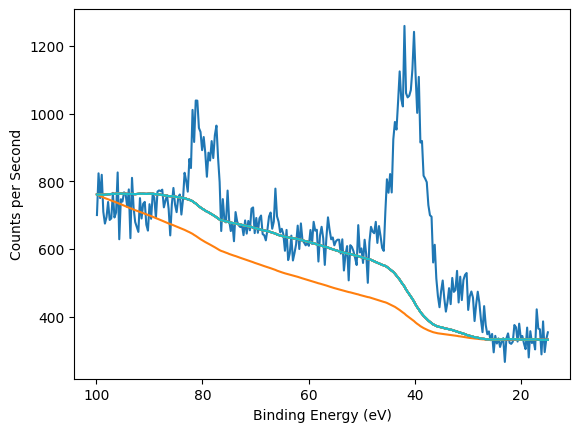

In [4]:
eV = data.spectra[20].eV
counts = data.spectra[20].counts
plt.plot(eV, counts)
for n in range(1, 10):
    plt.plot(data.spectra[20].eV, shirley_background(data.spectra[20], n))
boilerplate()

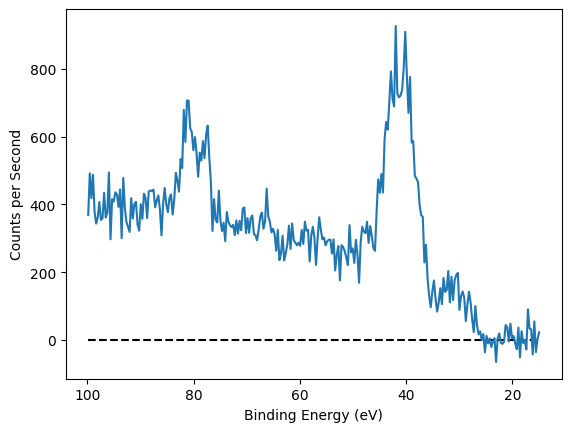

In [5]:
flat_background = np.mean(counts[-5:])
plt.hlines(0, max(eV), min(eV), color = 'black', ls = 'dashed')
plt.plot(eV, counts - flat_background)
boilerplate()

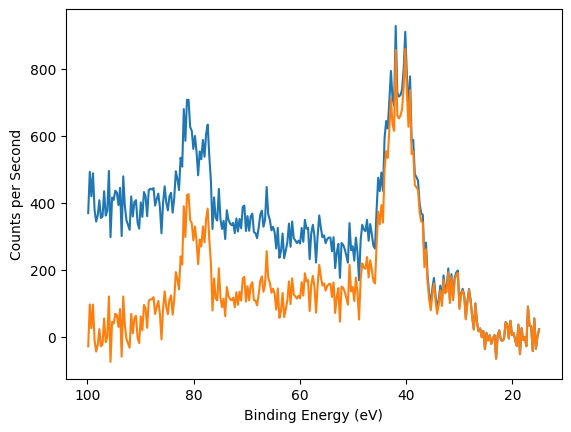

In [6]:
def iterate_shirley_background(counts):
    shirley_parameter = np.mean(counts[:10])
    sum_counts = np.sum(counts)
    sum_past_point = []
    for n in range(0, len(counts)):
        sum_past_point.append(np.sum(counts[n:]))
    sum_past_point = np.array(sum_past_point)
    return counts - shirley_parameter*sum_past_point/sum_counts

def shirley_background_subtraction(counts, n_iterations):
    flat_background = np.mean(counts[-10:])
    results = [counts - flat_background]
    for n in range(0, n_iterations):
        results.append(iterate_shirley_background(results[-1]))
    return results

def shirley_background(counts, n_iterations):
    corrected_counts = shirley_background_subtraction(counts, n_iterations)
    return [counts - corrected for corrected in corrected_counts]

plt.plot(eV, counts - flat_background)
plt.plot(eV, iterate_shirley_background(counts - flat_background))
boilerplate()

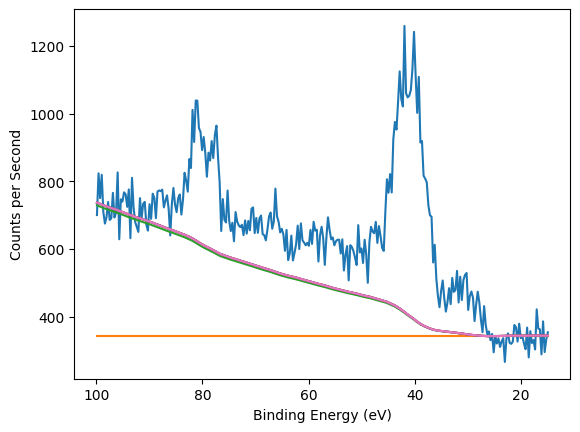

In [7]:
plt.plot(eV, counts)
for background in shirley_background(counts, 5):
    plt.plot(eV, background)
boilerplate()

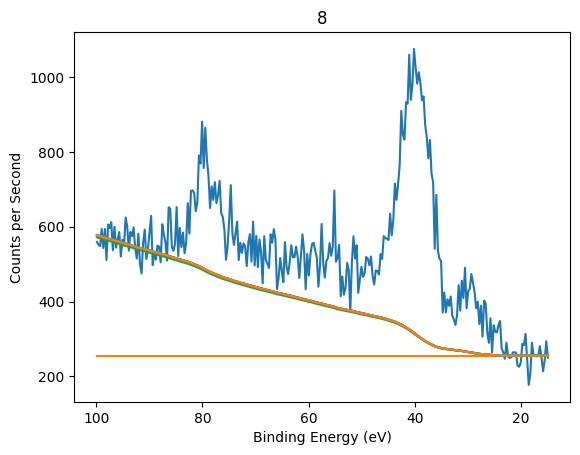

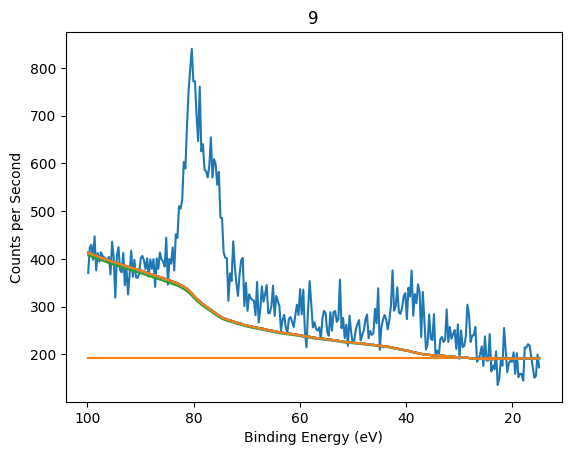

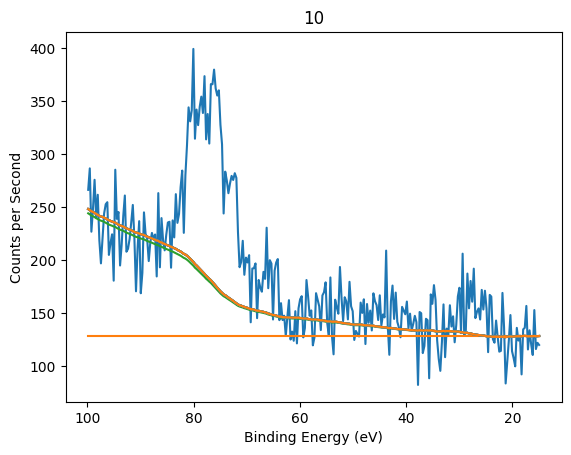

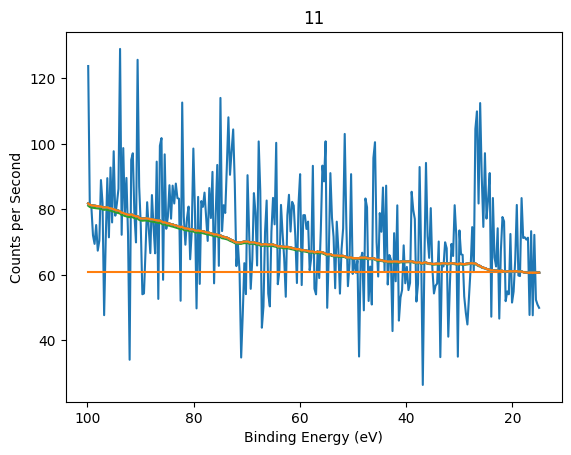

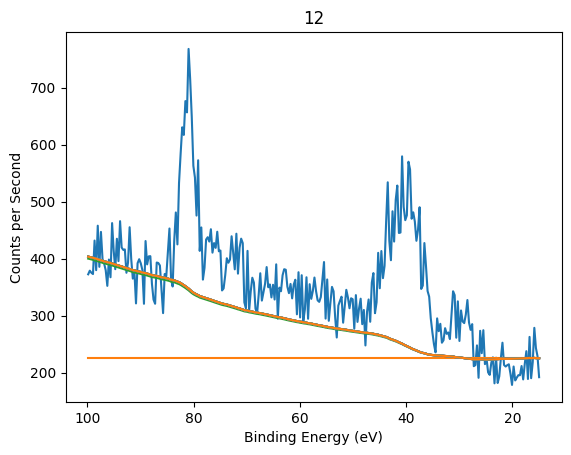

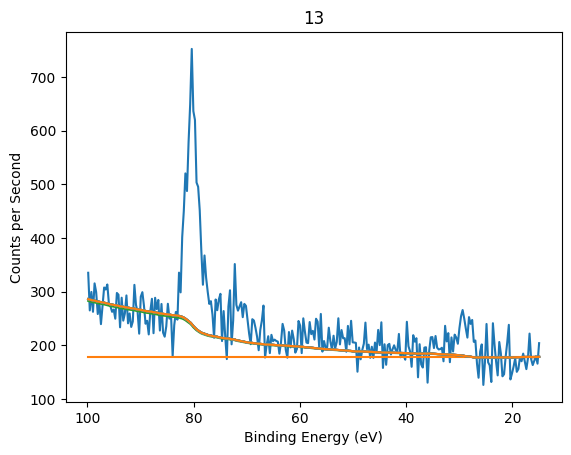

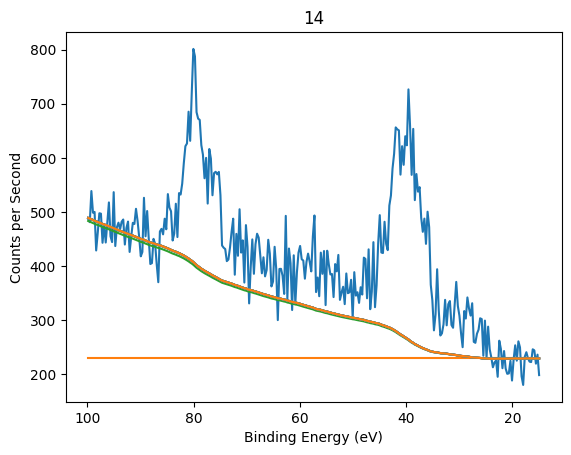

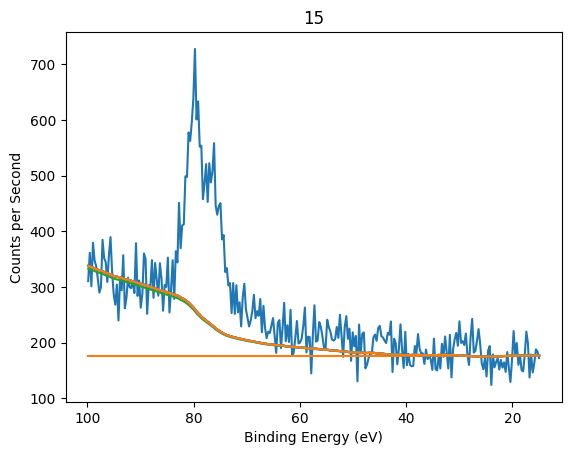

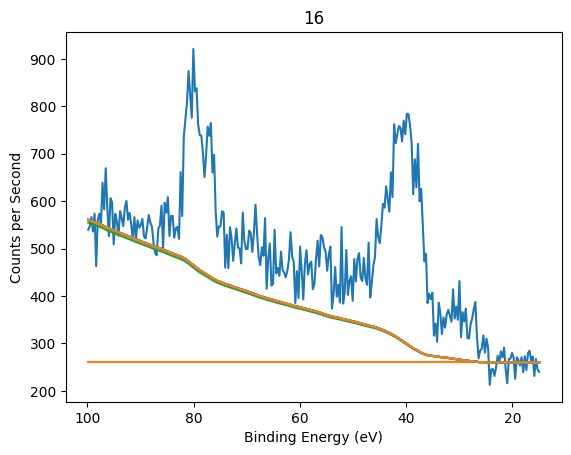

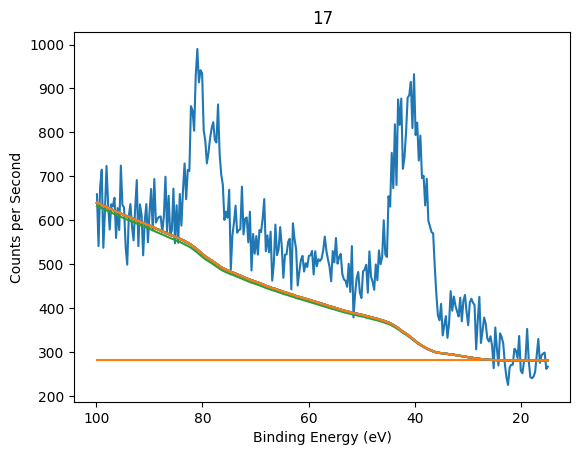

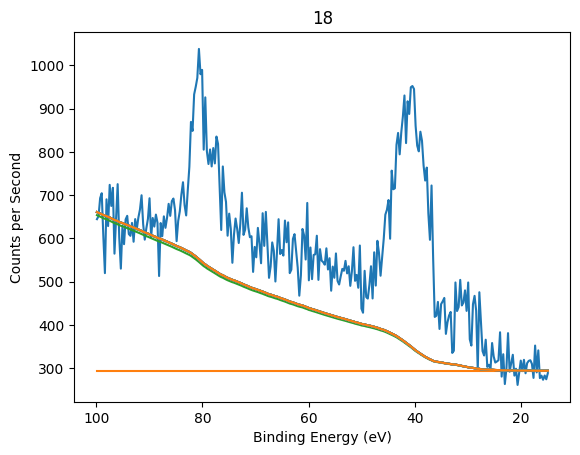

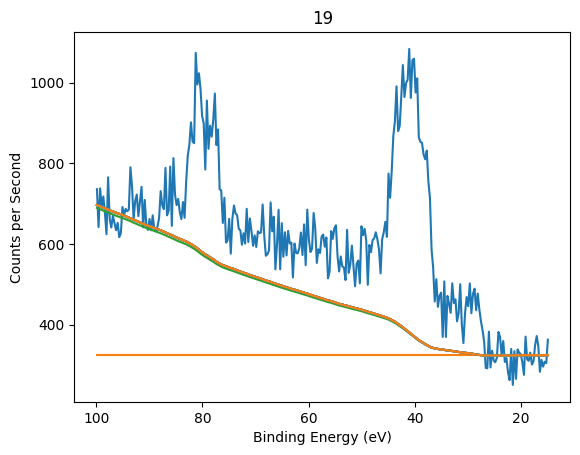

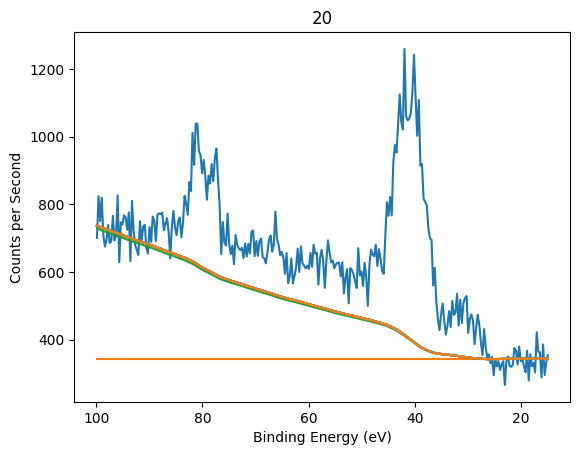

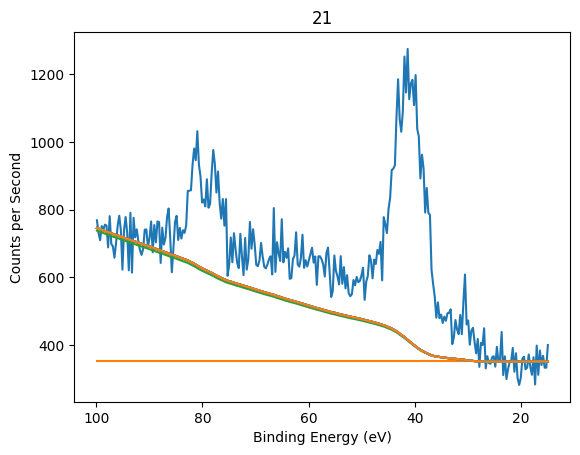

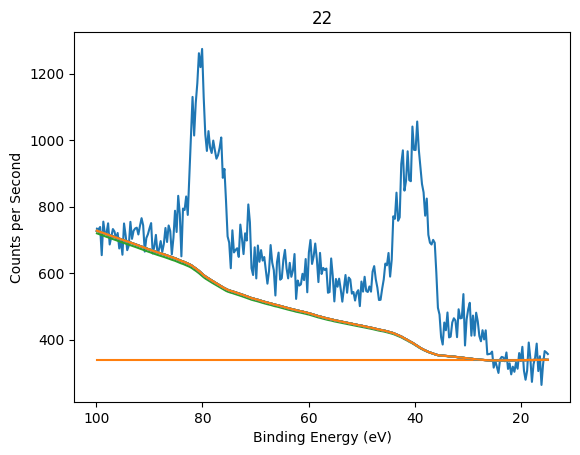

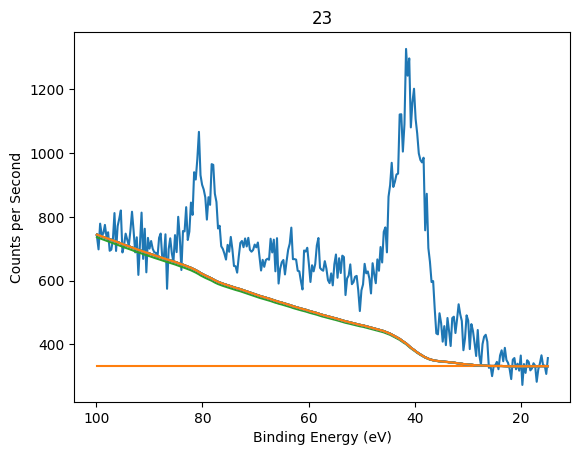

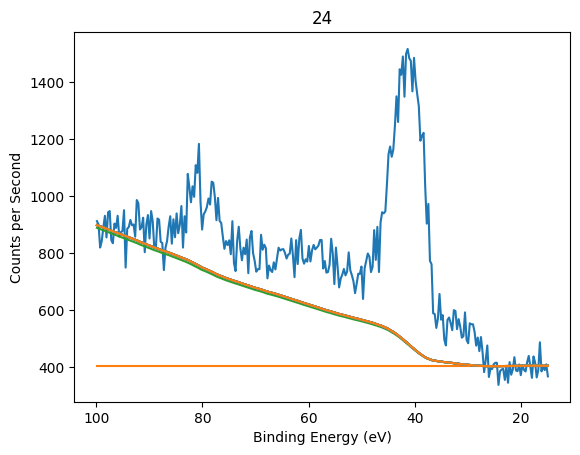

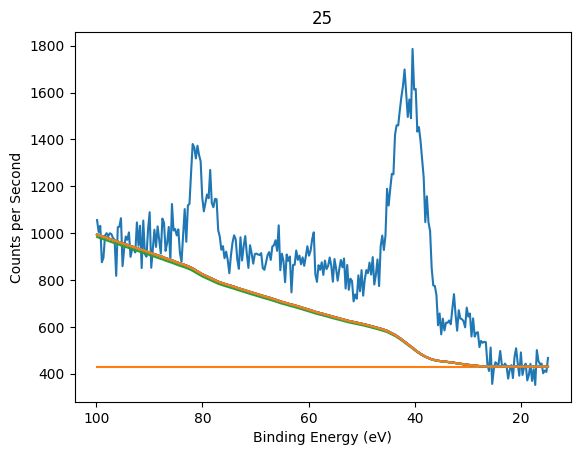

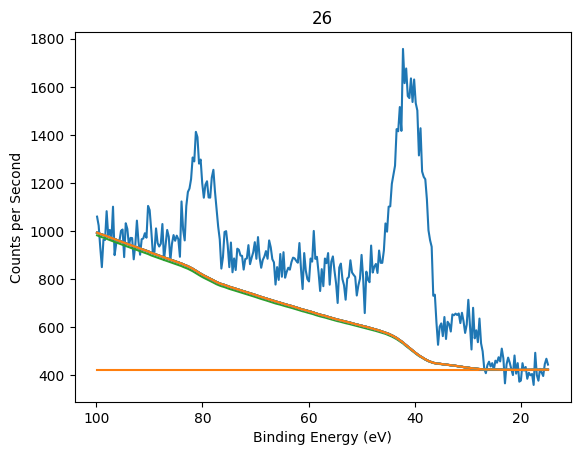

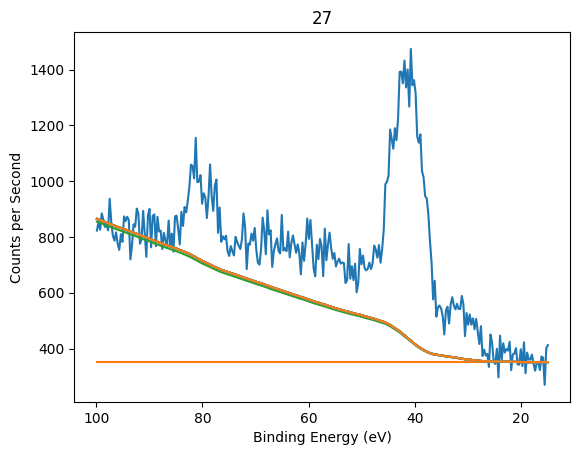

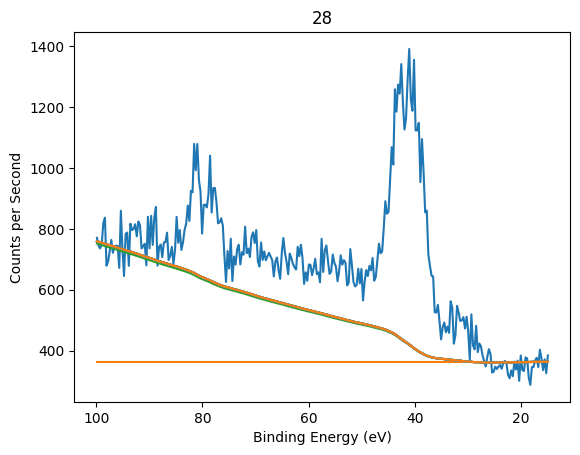

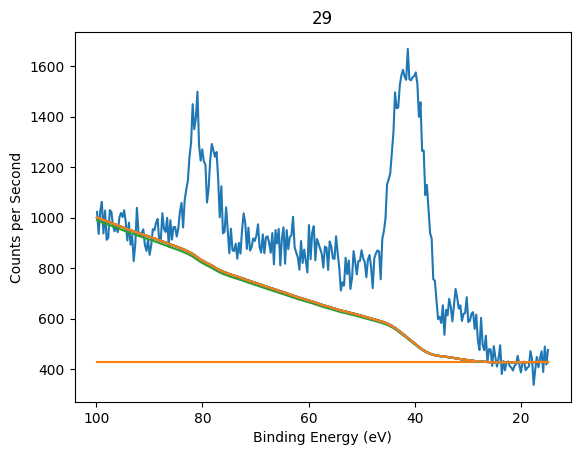

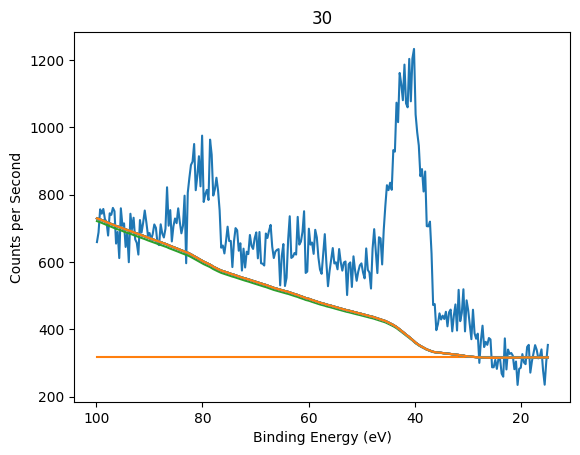

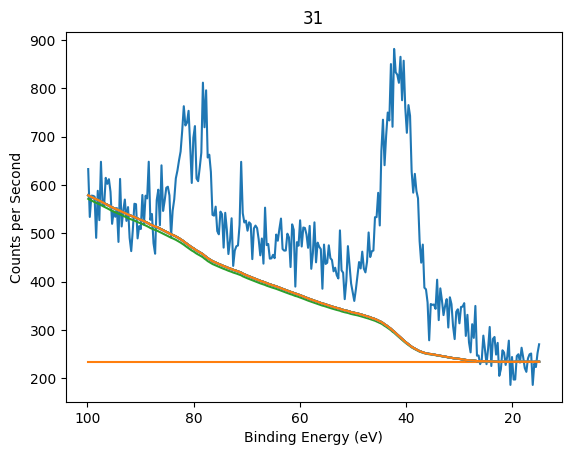

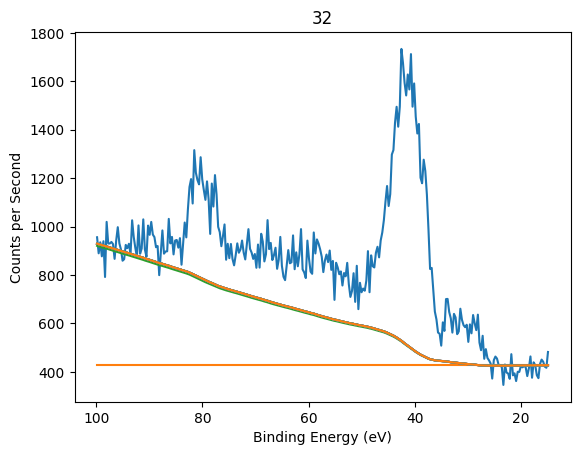

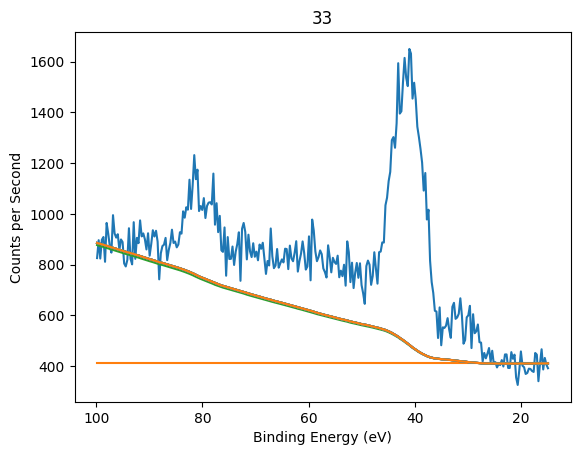

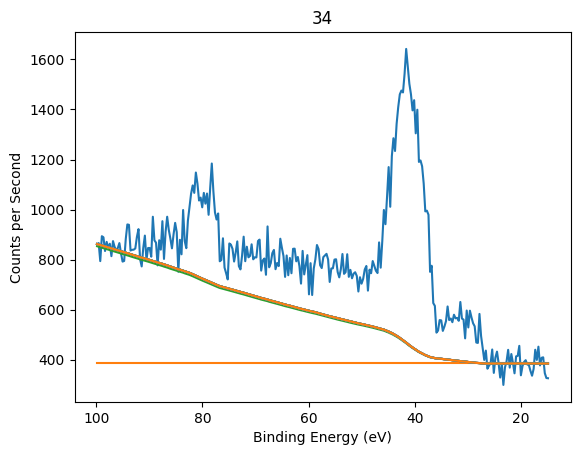

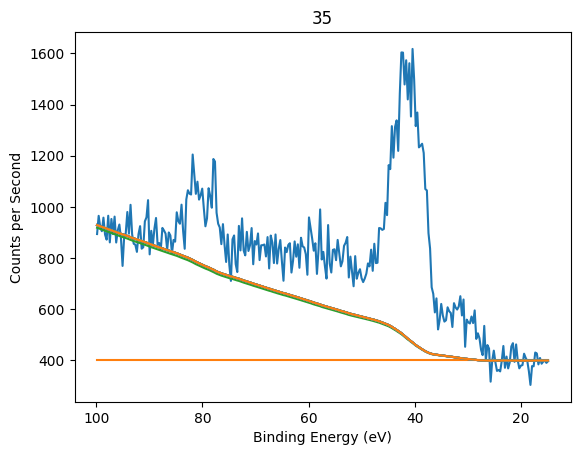

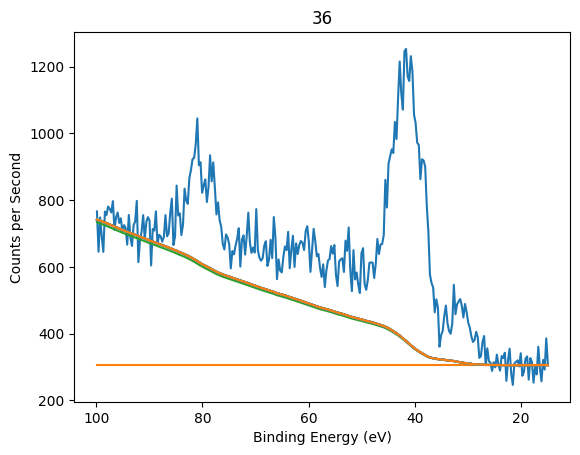

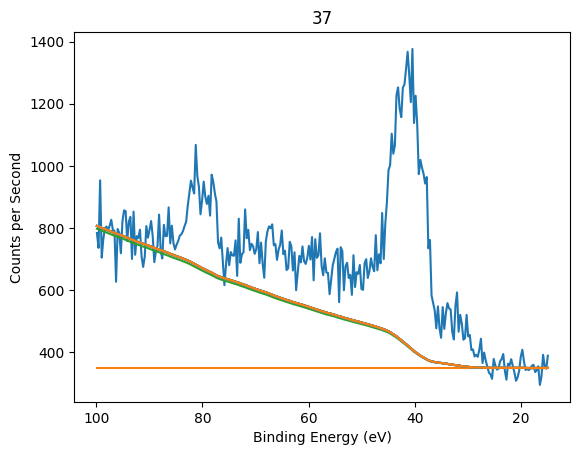

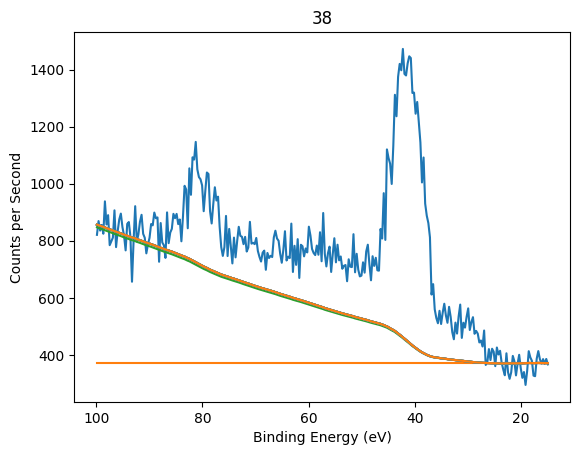

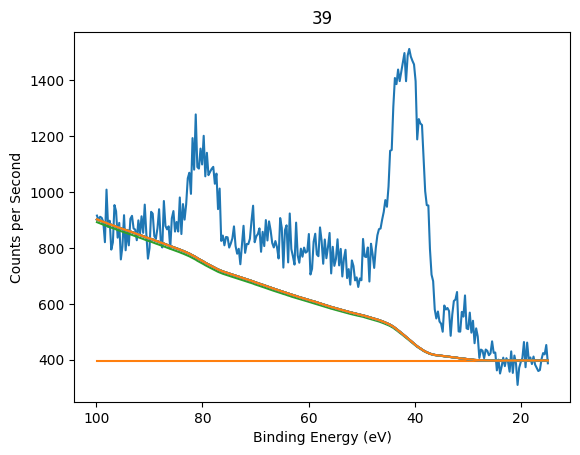

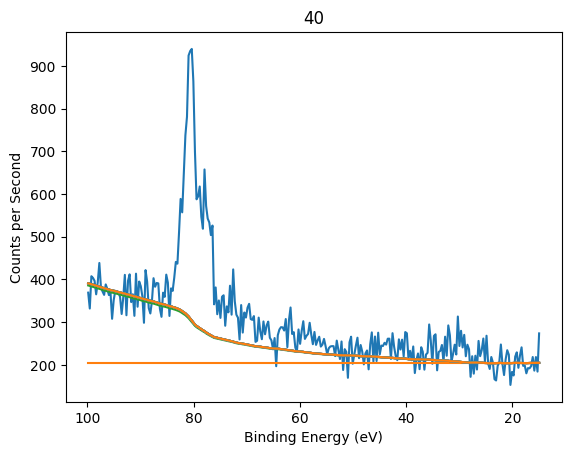

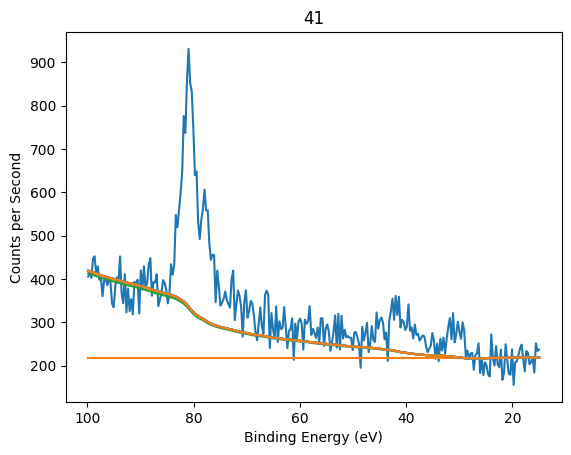

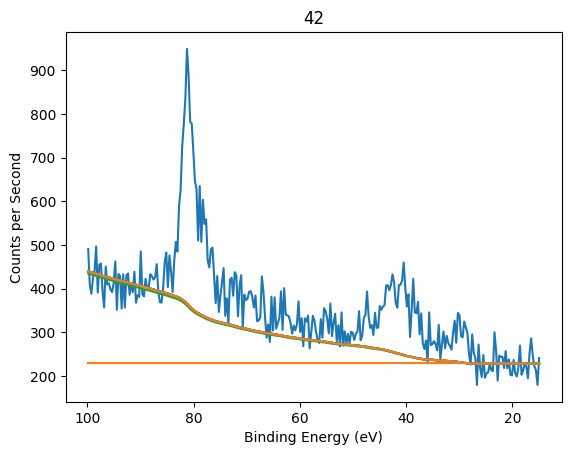

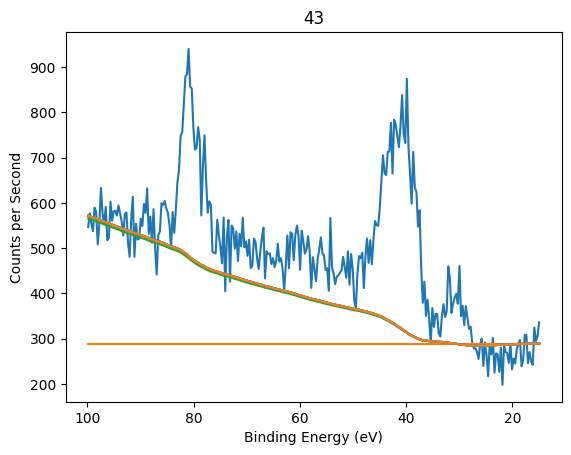

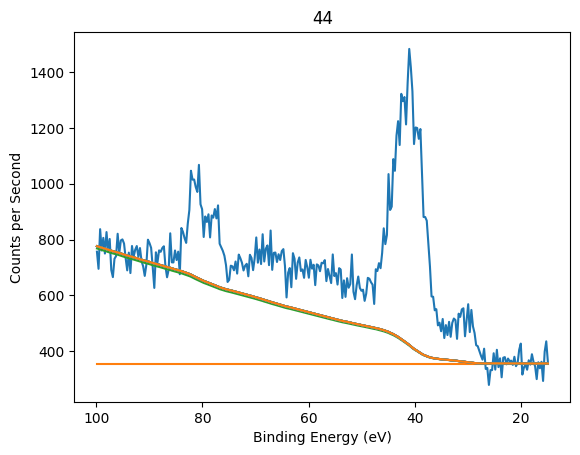

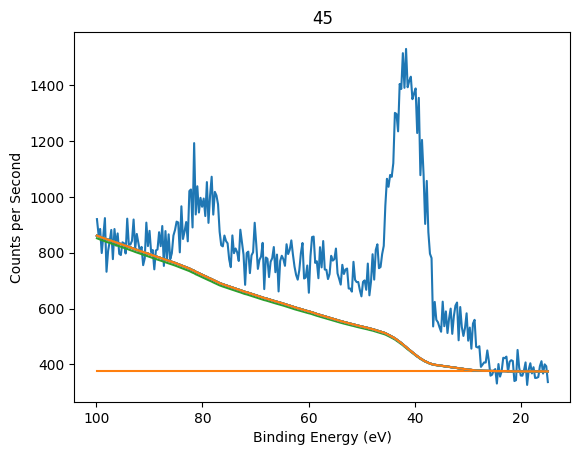

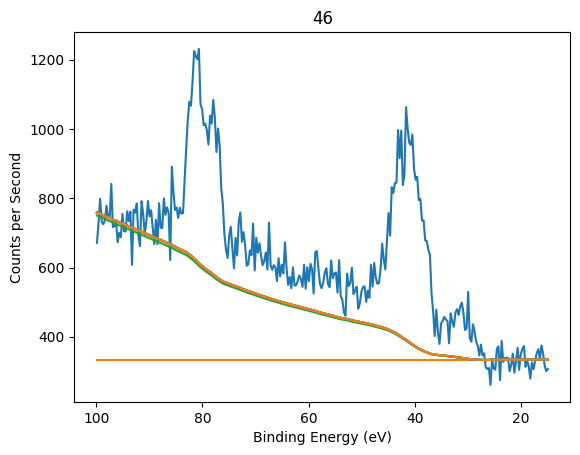

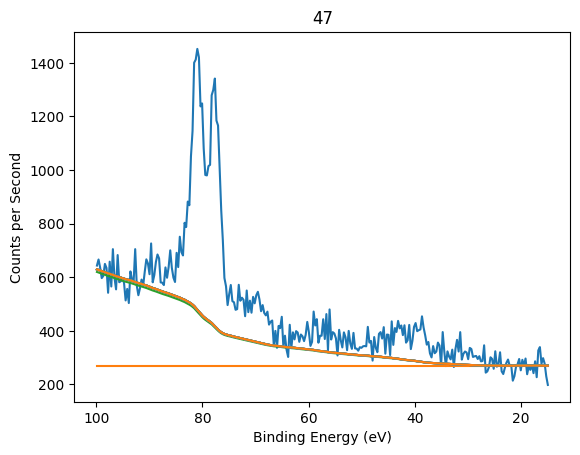

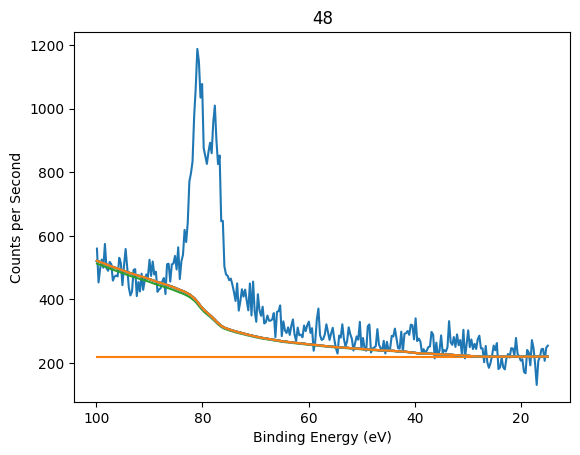

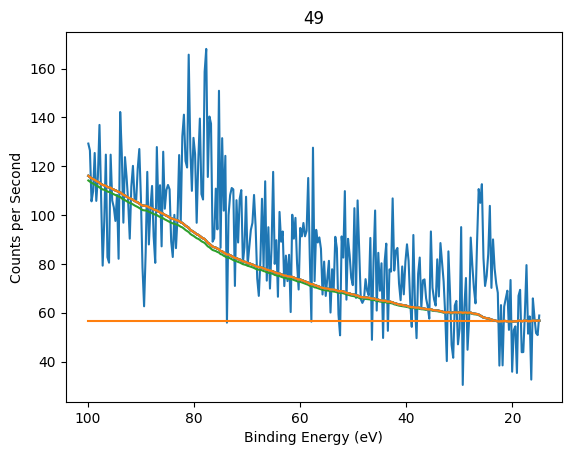

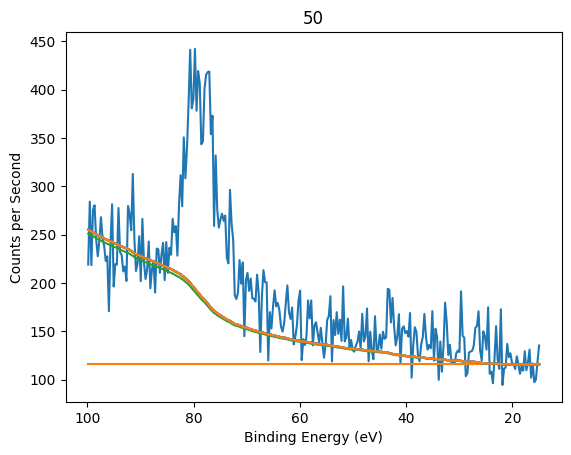

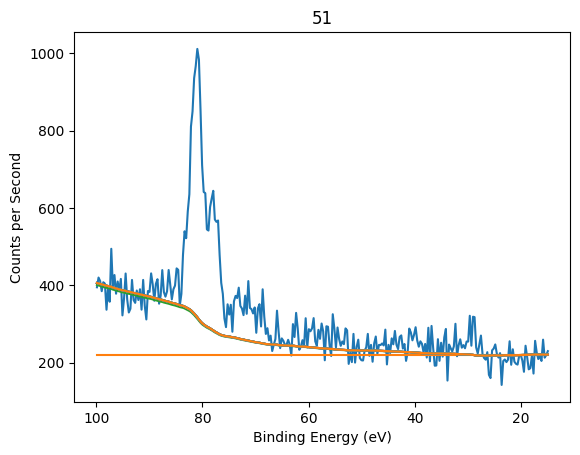

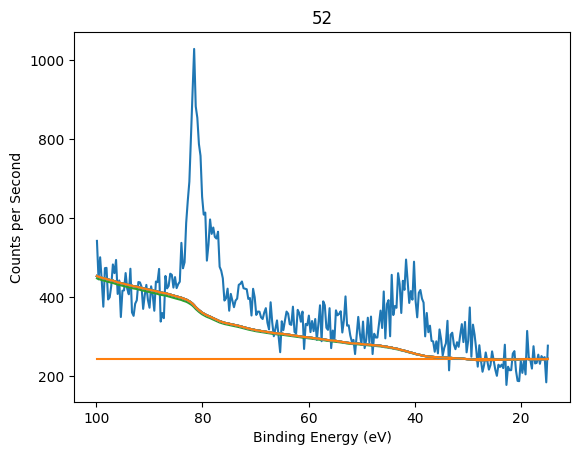

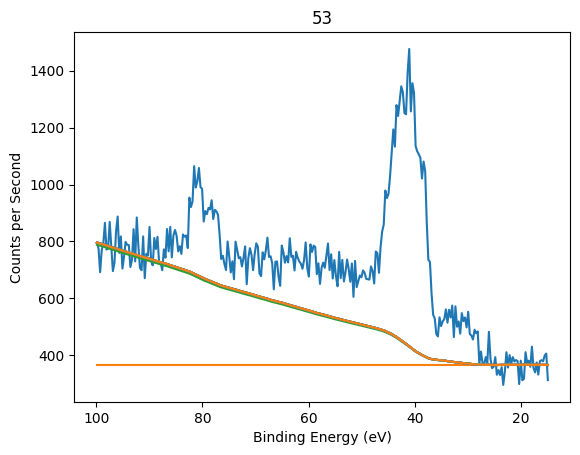

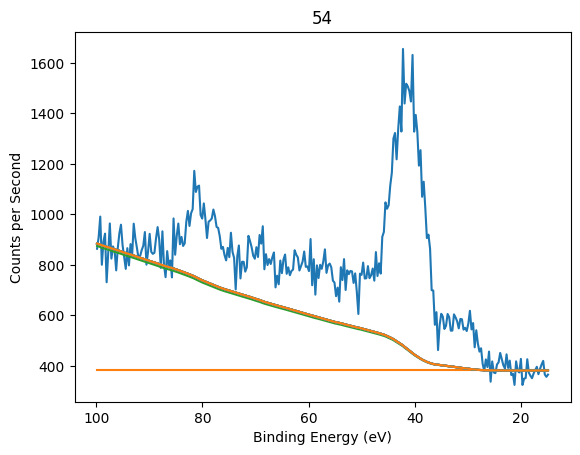

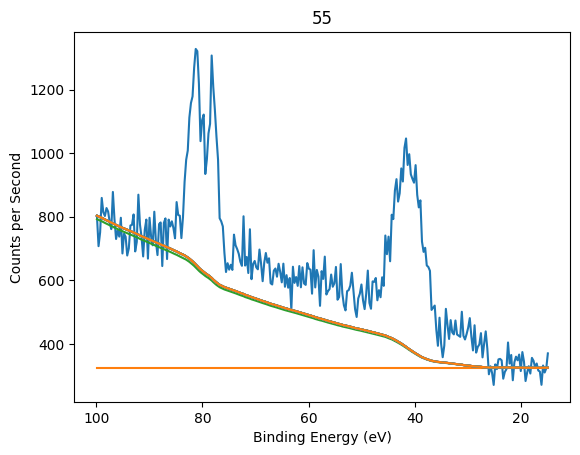

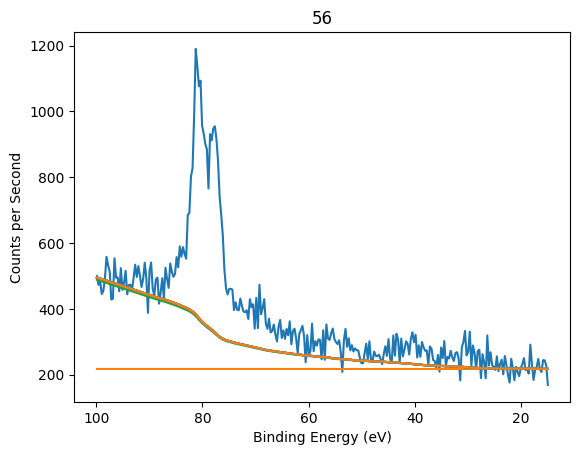

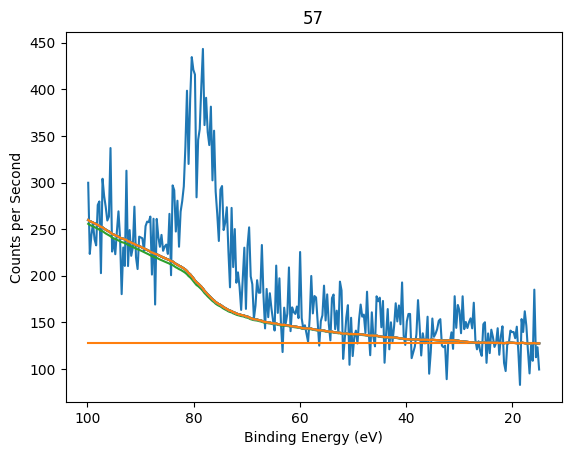

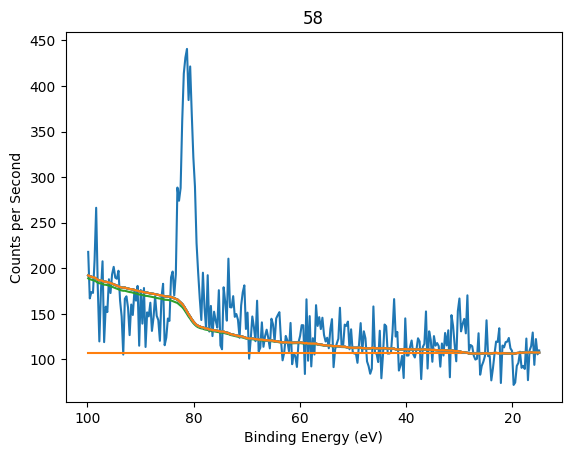

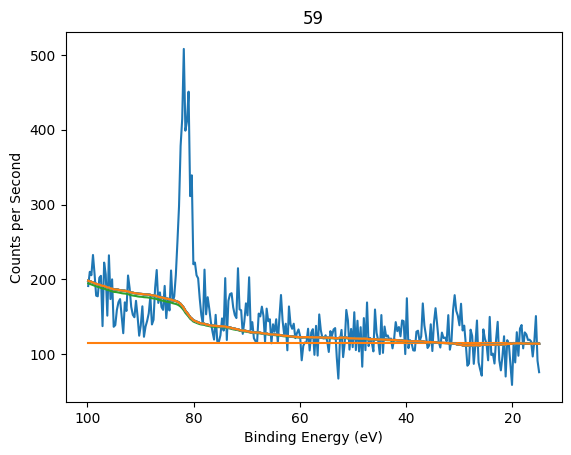

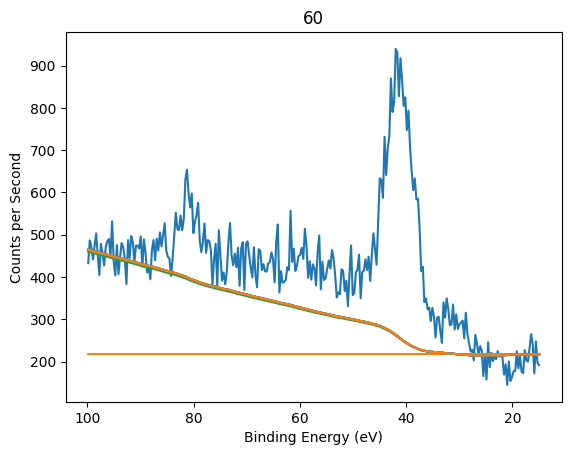

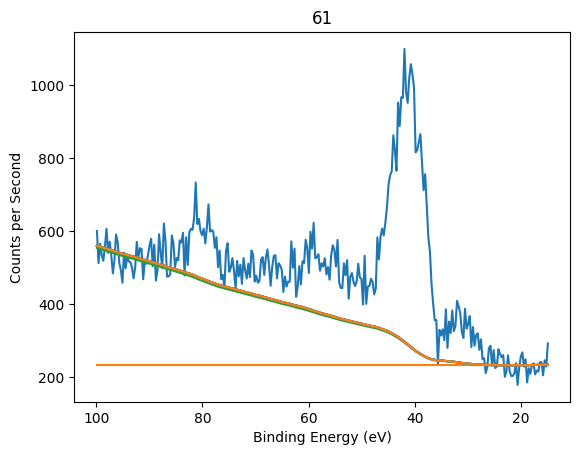

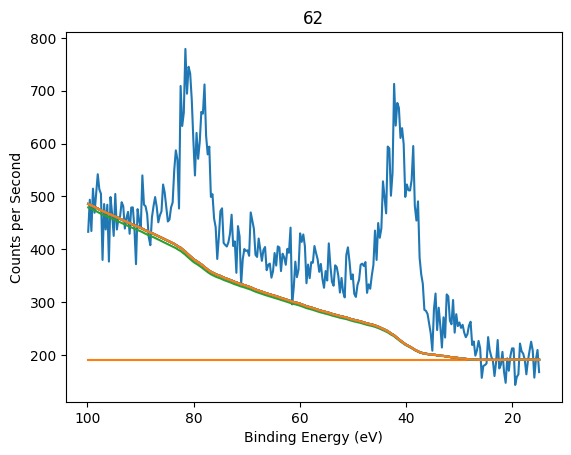

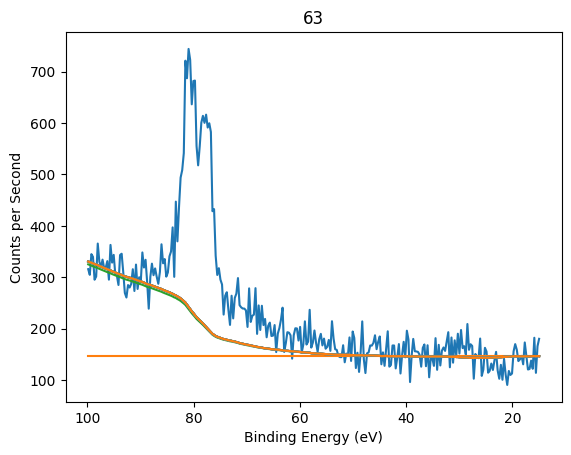

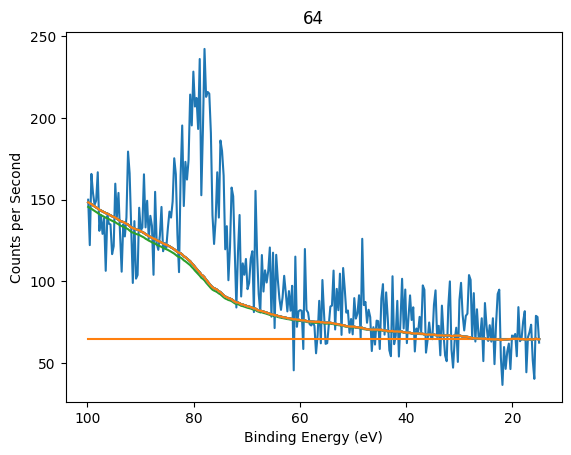

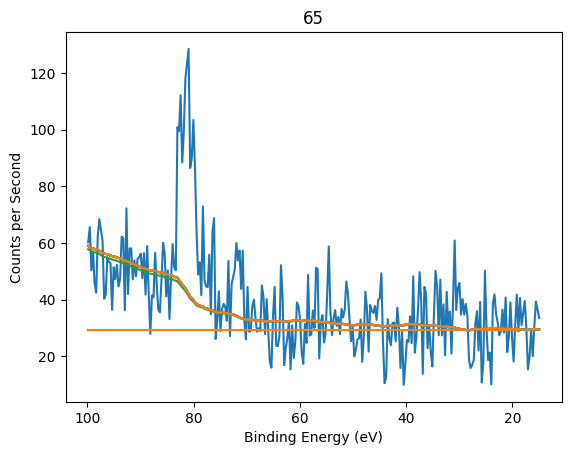

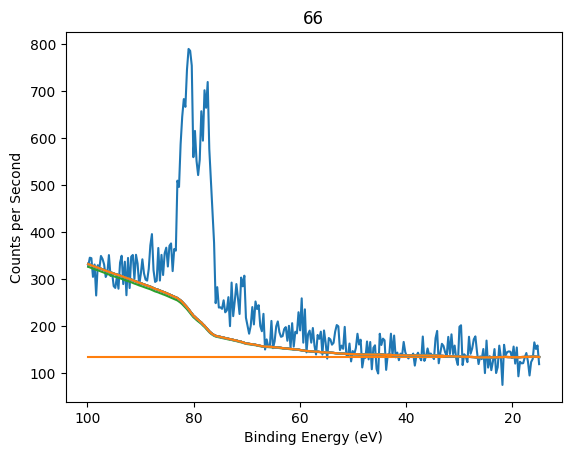

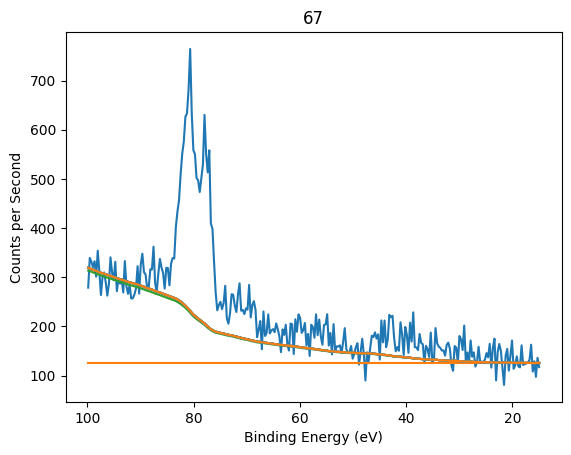

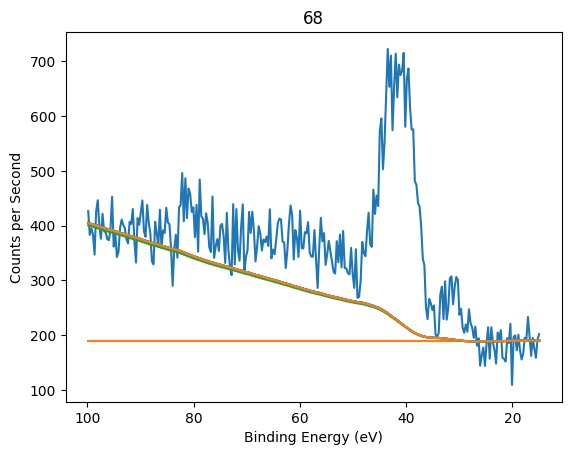

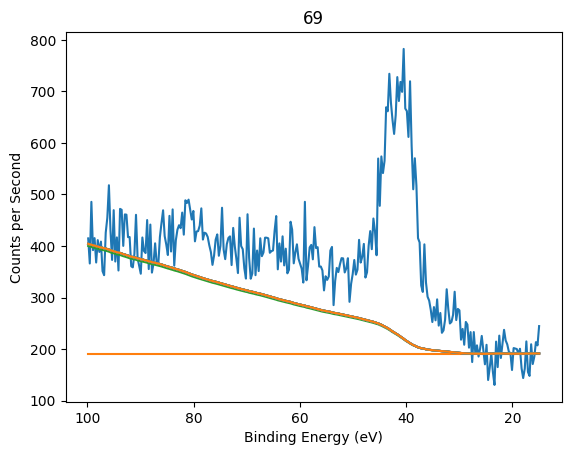

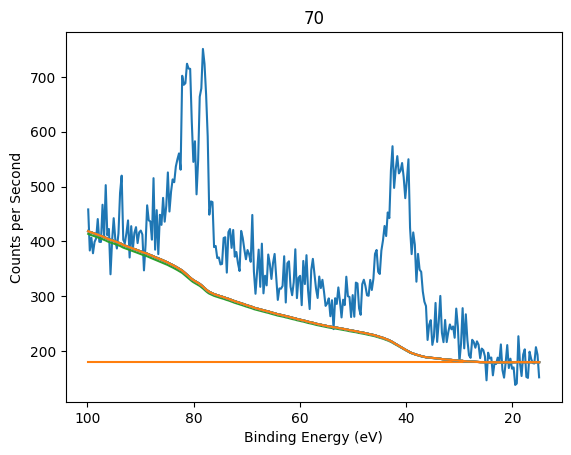

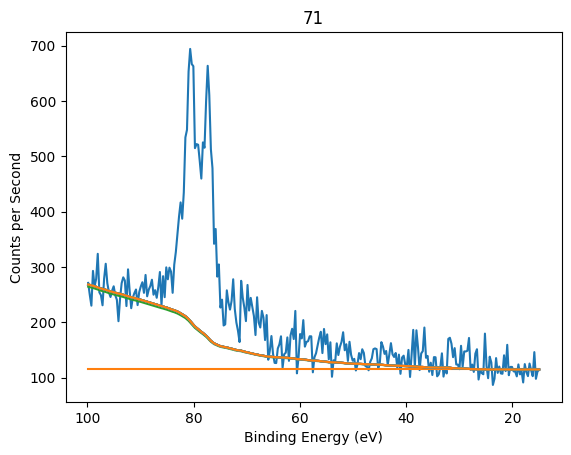

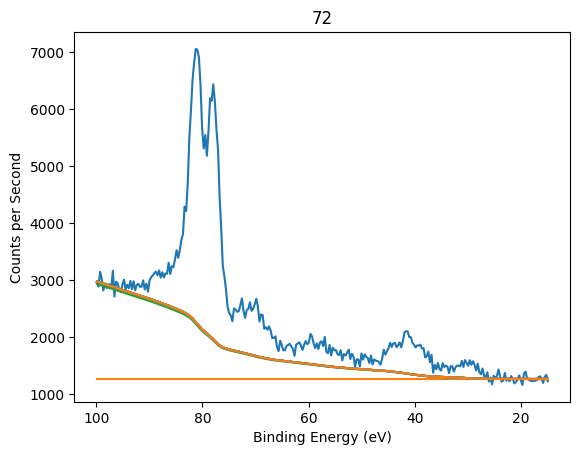

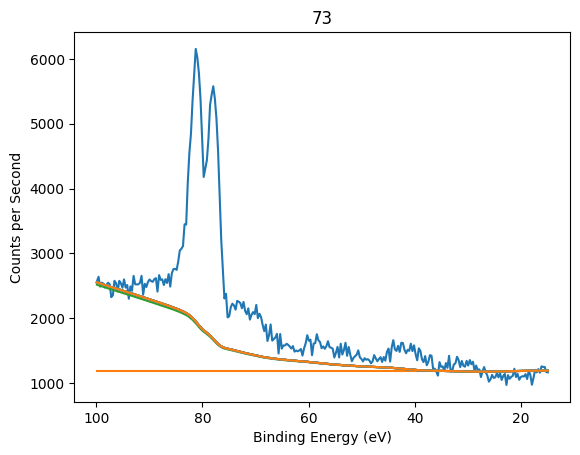

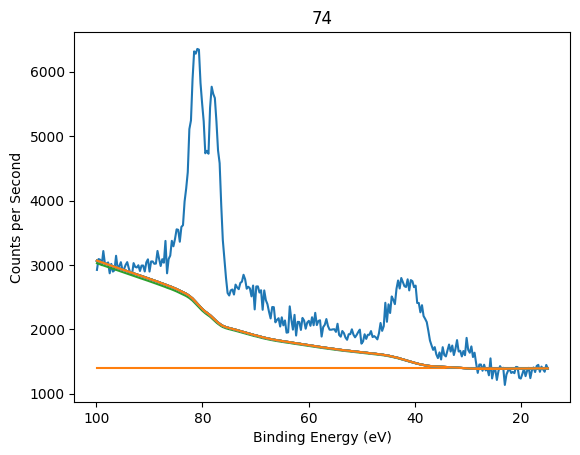

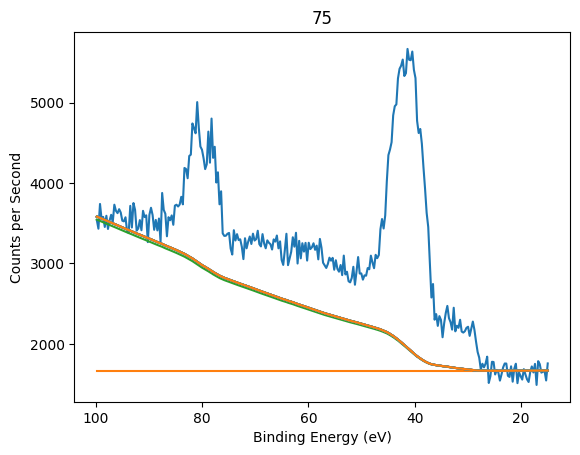

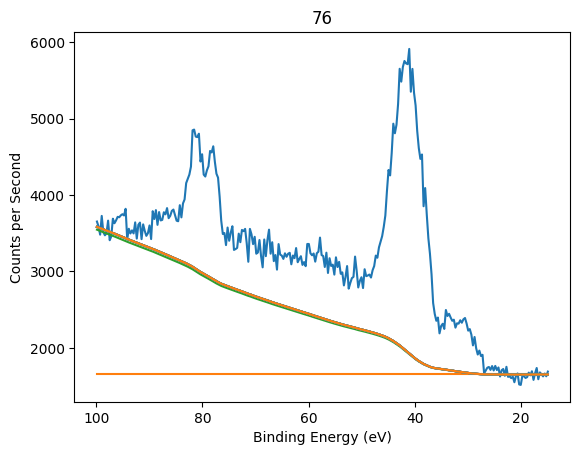

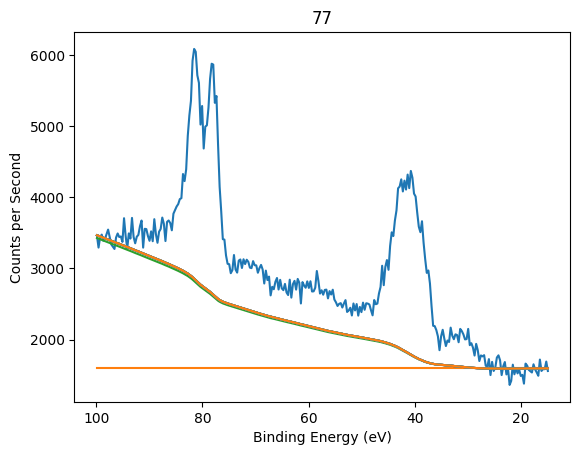

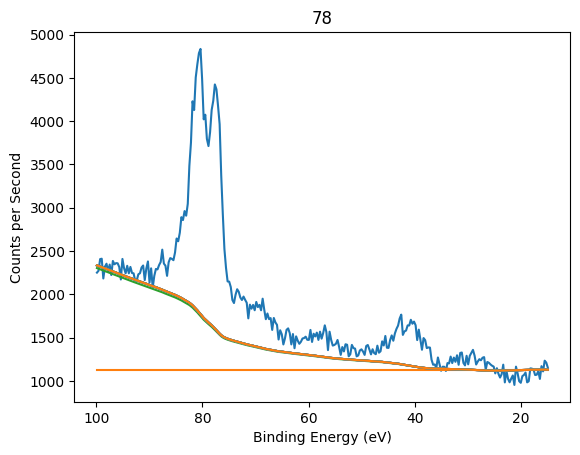

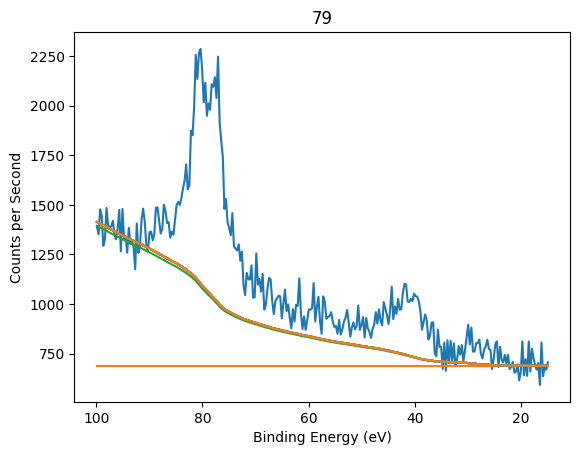

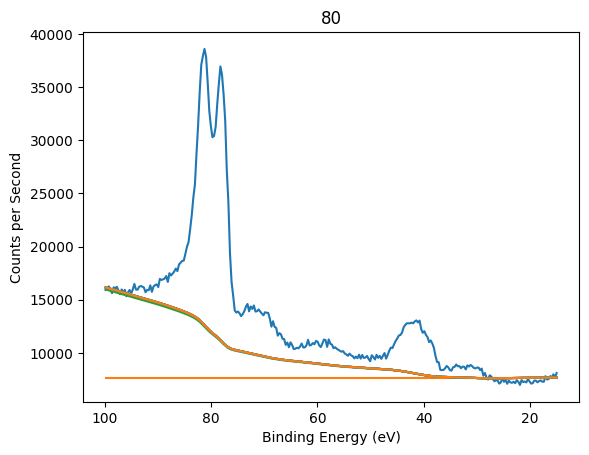

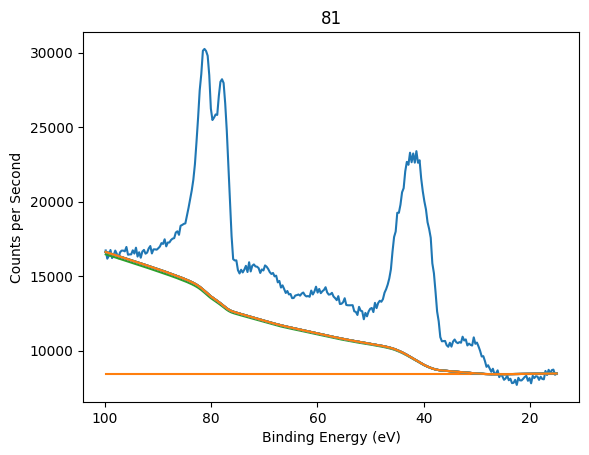

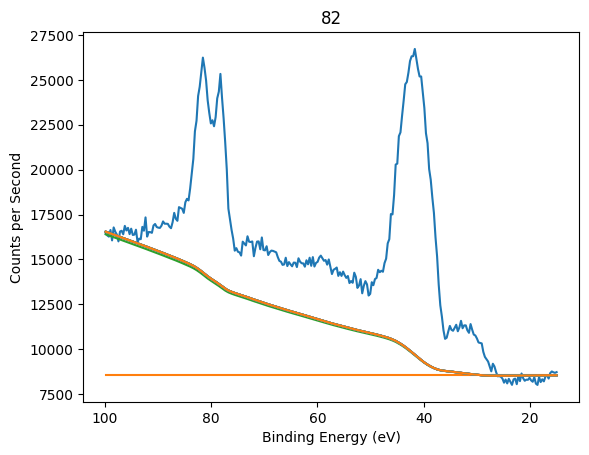

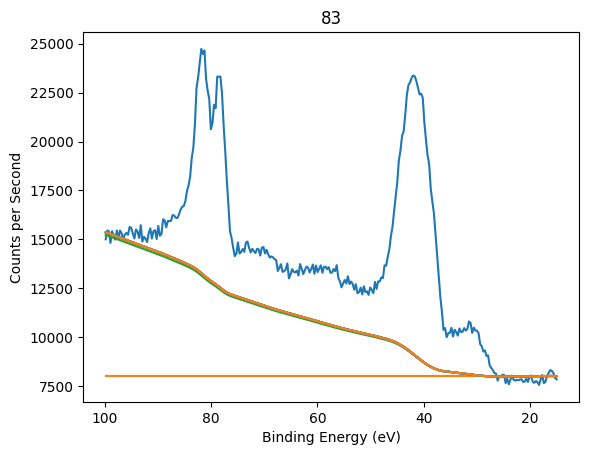

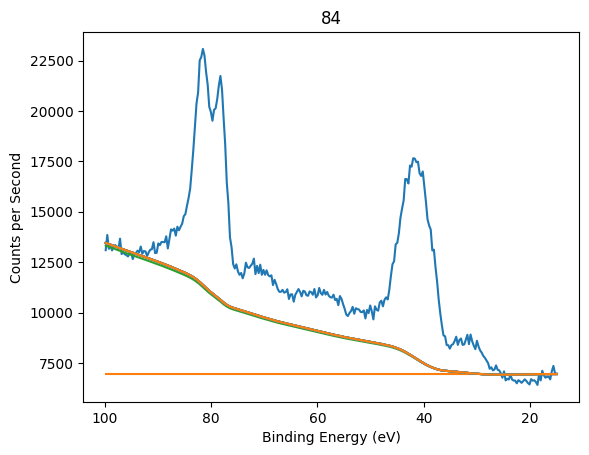

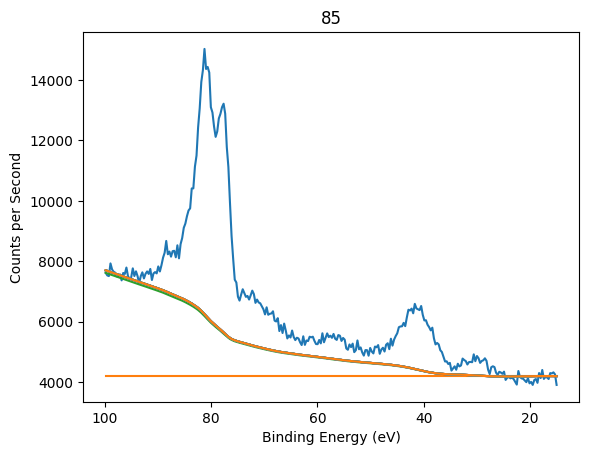

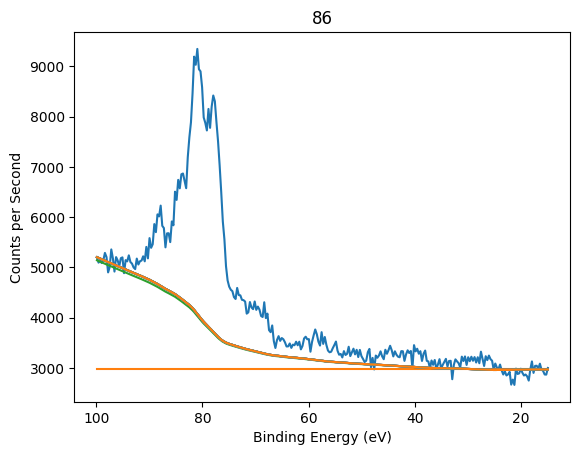

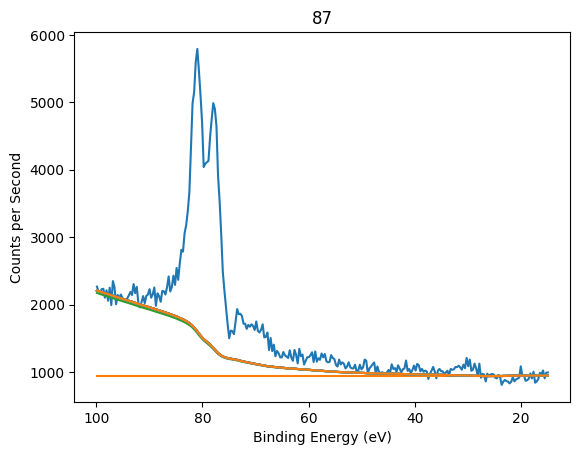

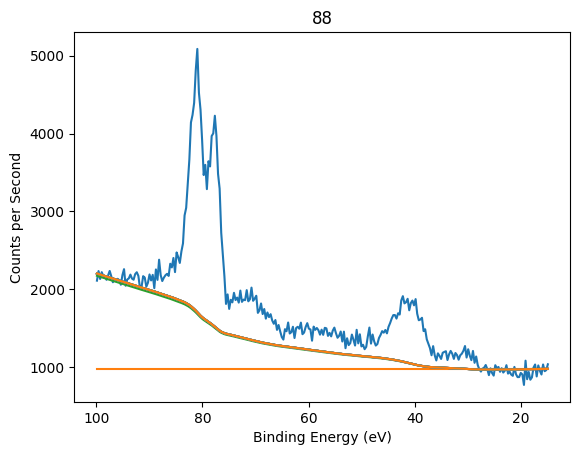

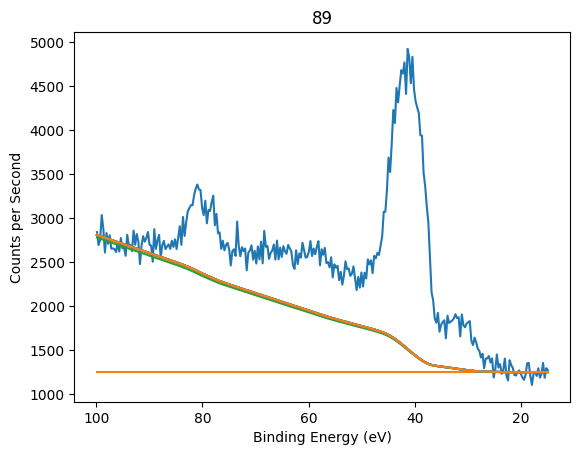

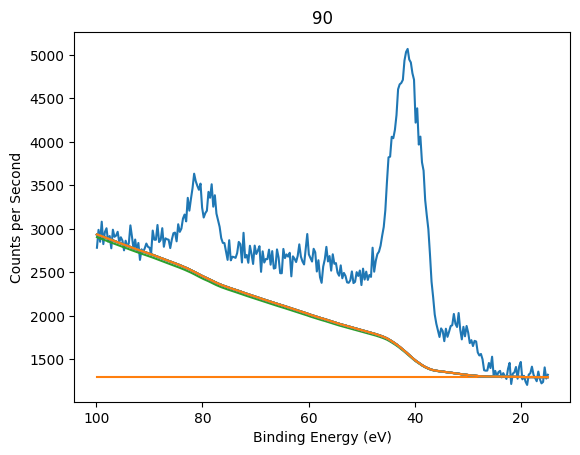

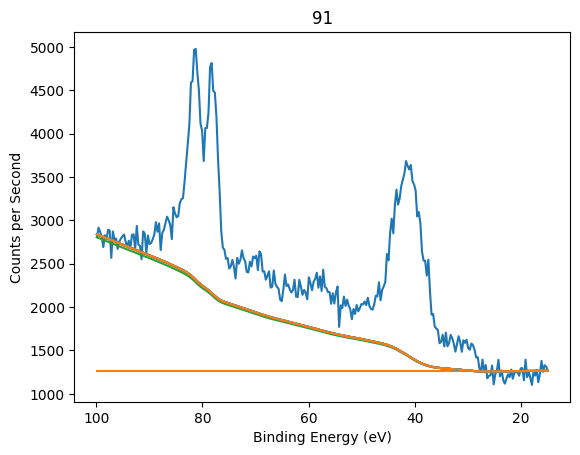

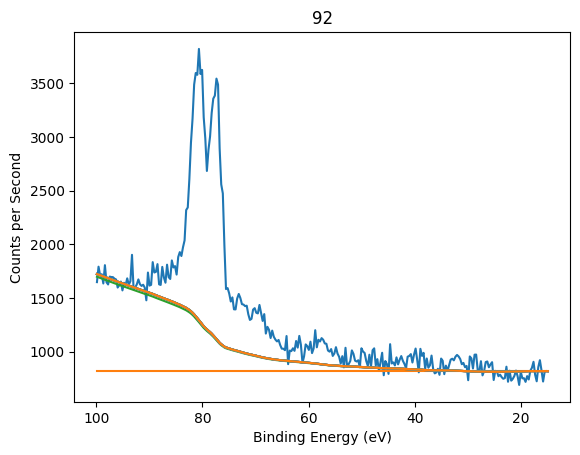

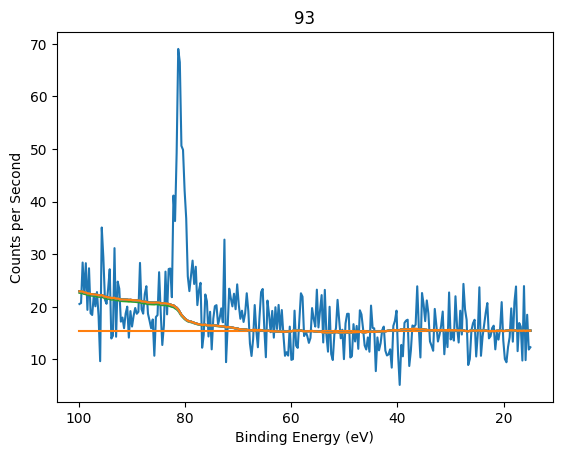

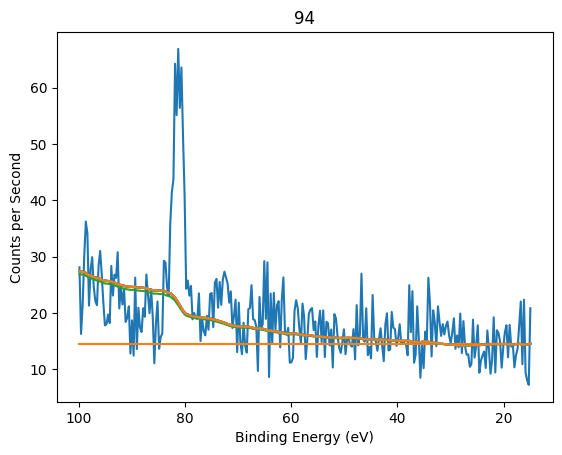

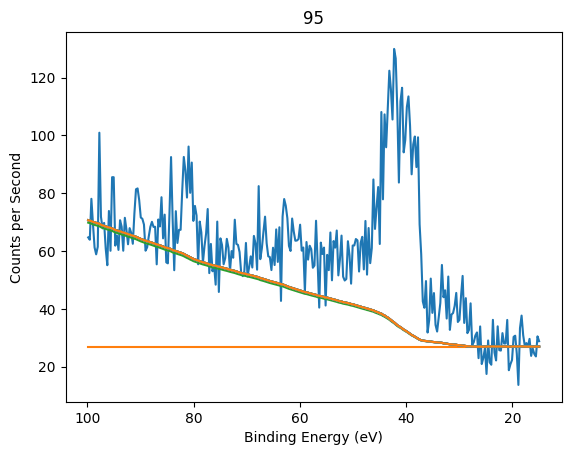

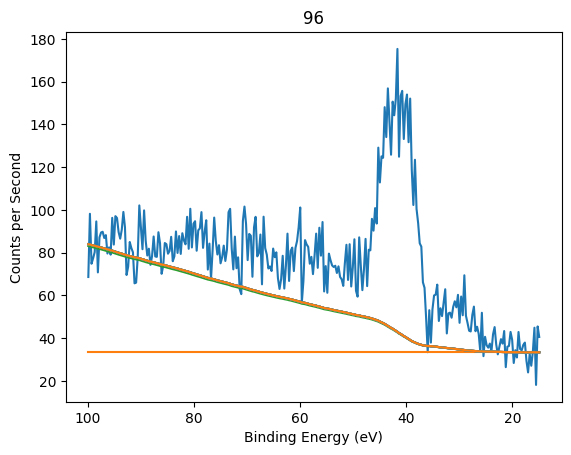

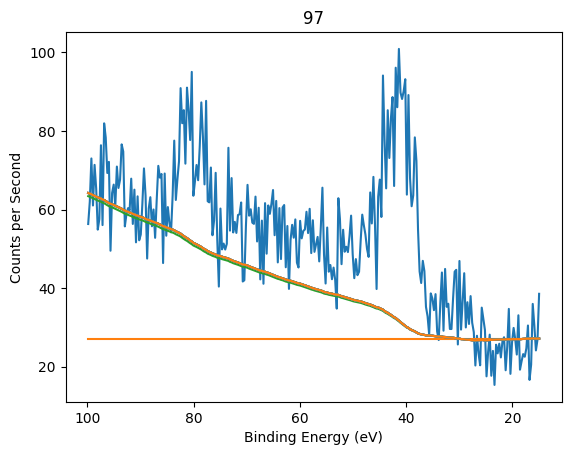

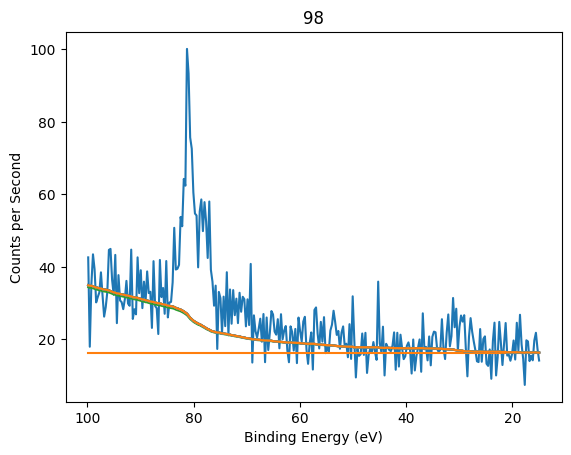

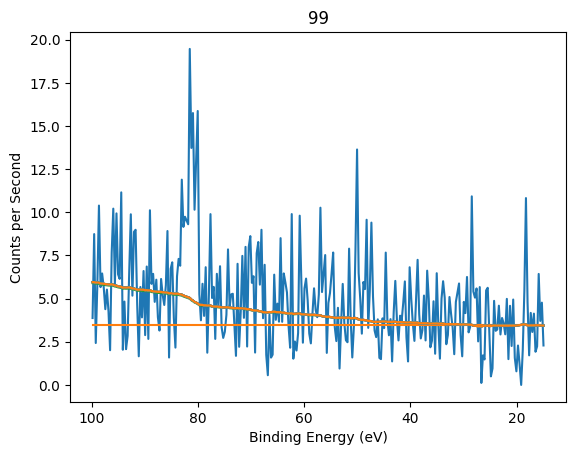

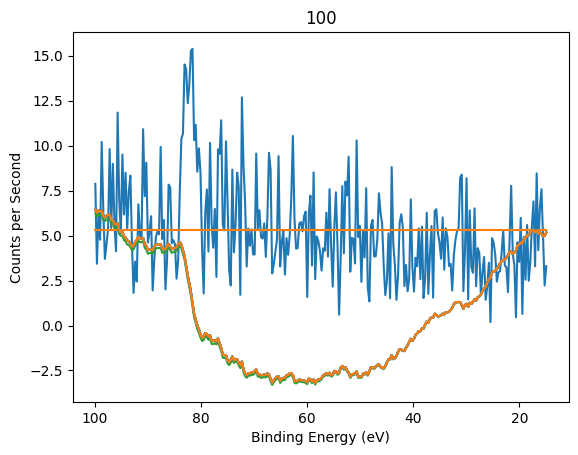

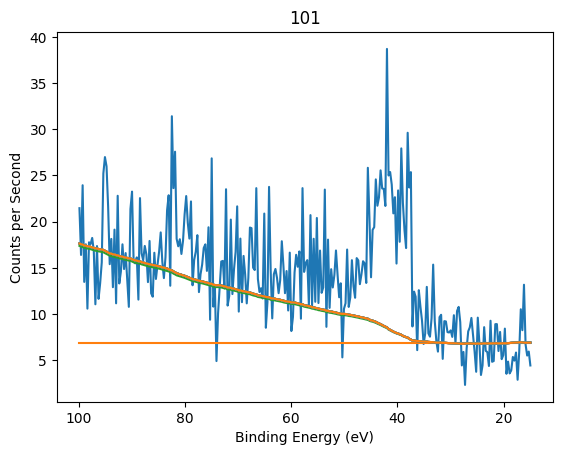

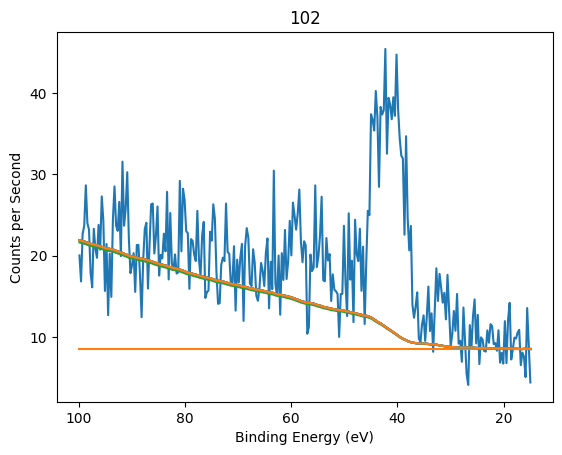

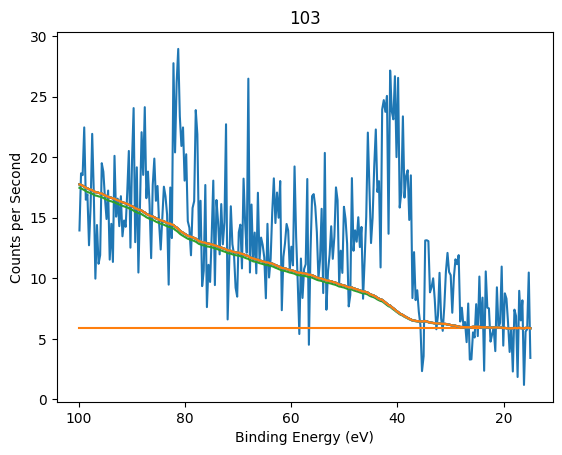

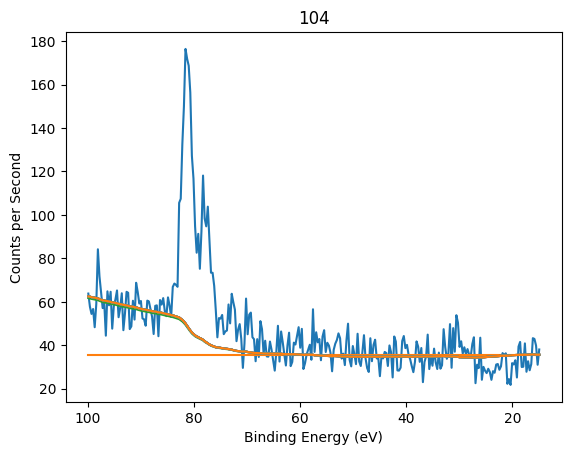

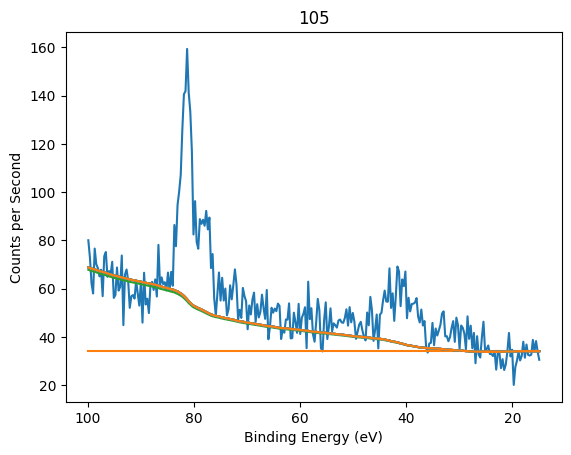

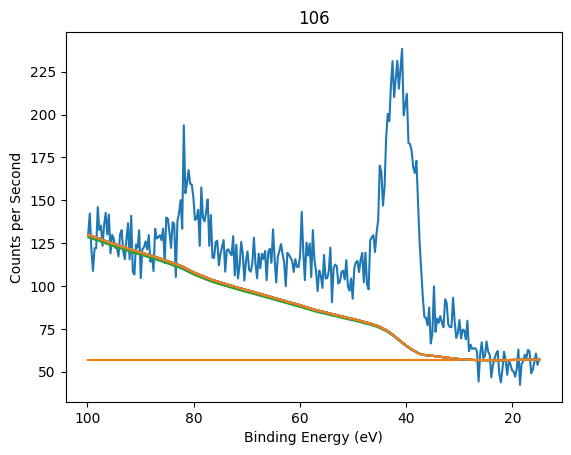

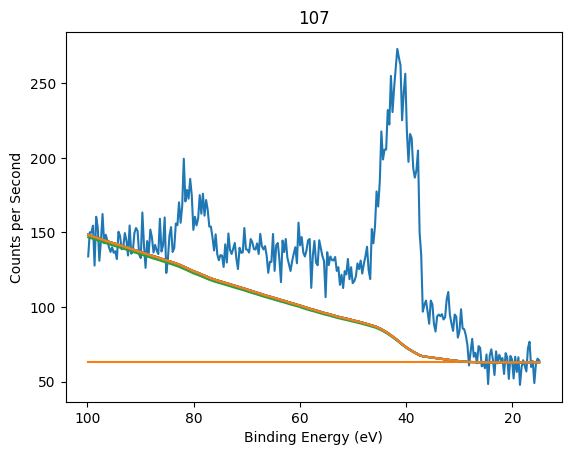

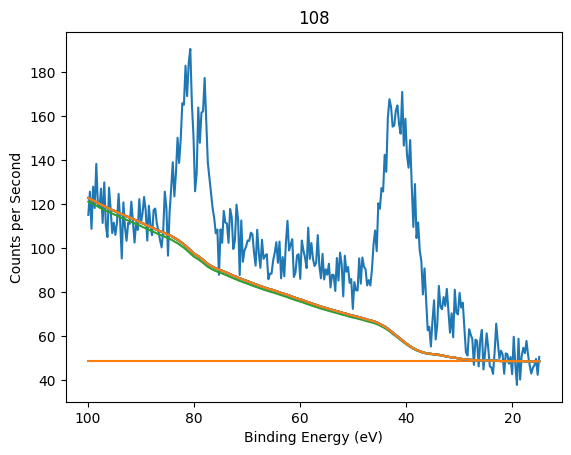

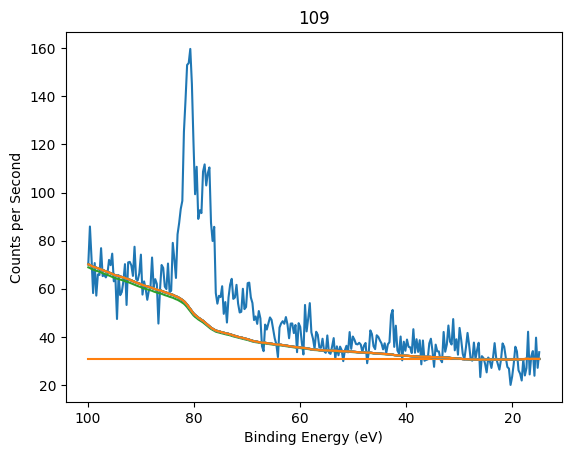

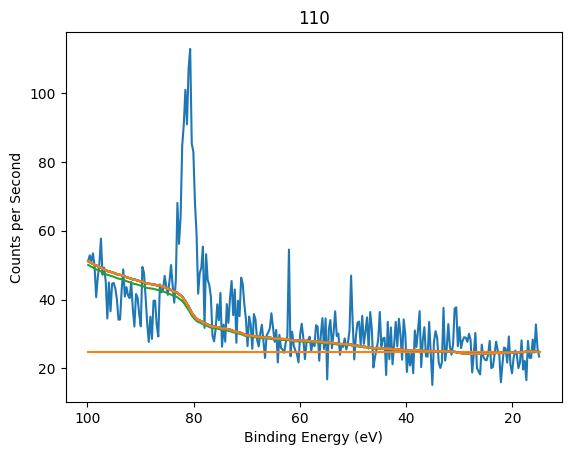

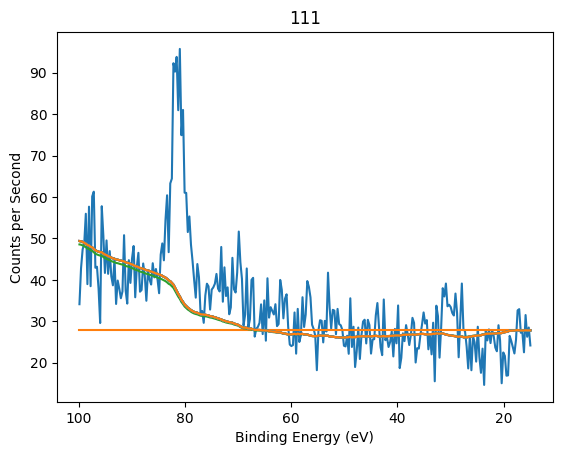

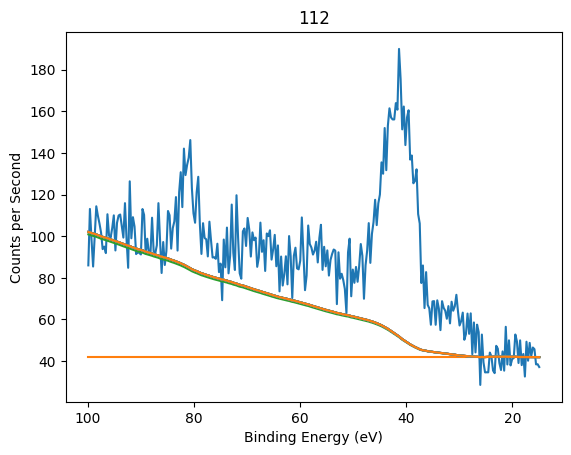

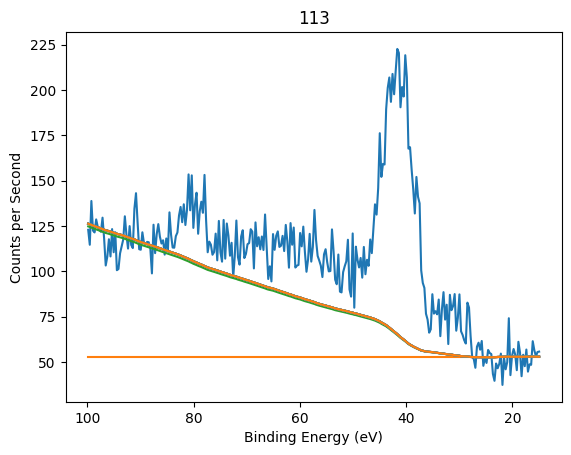

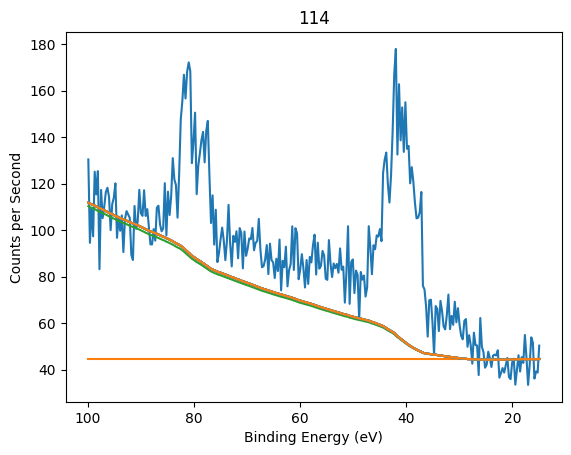

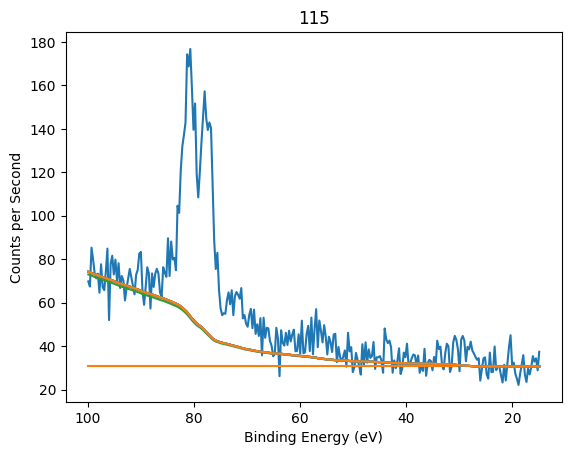

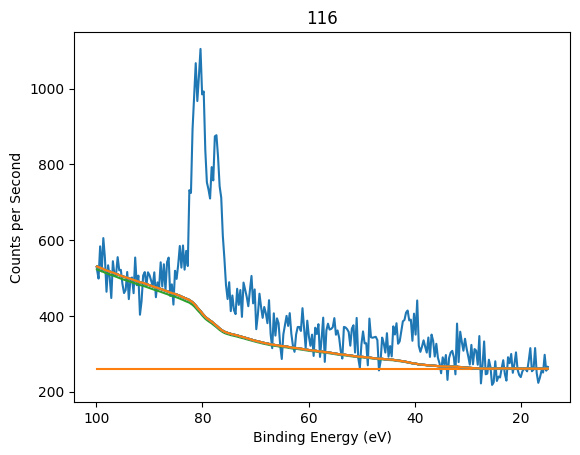

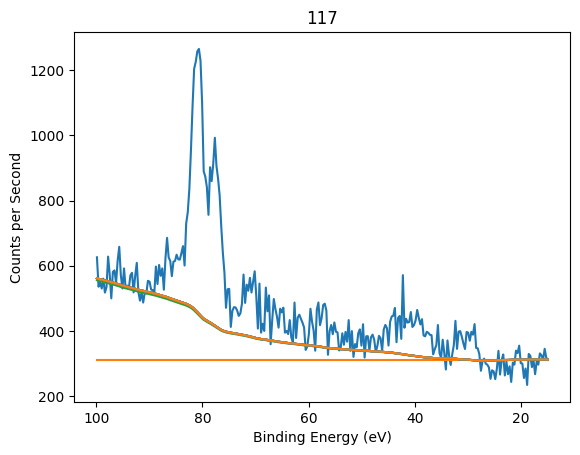

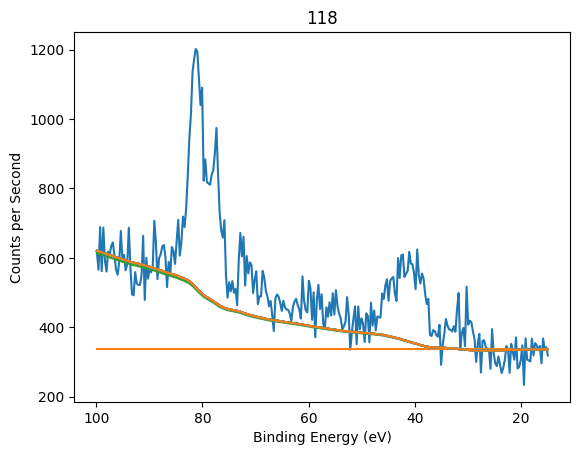

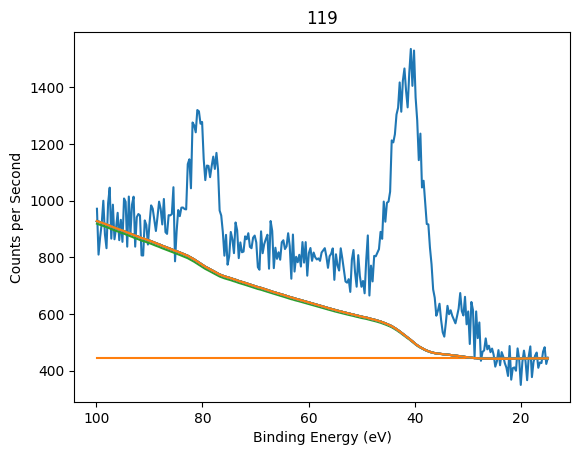

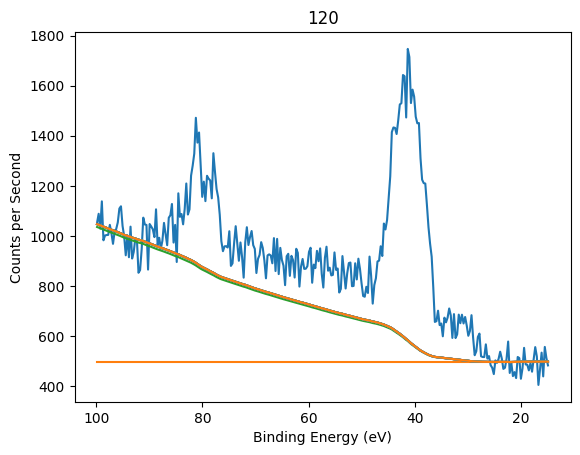

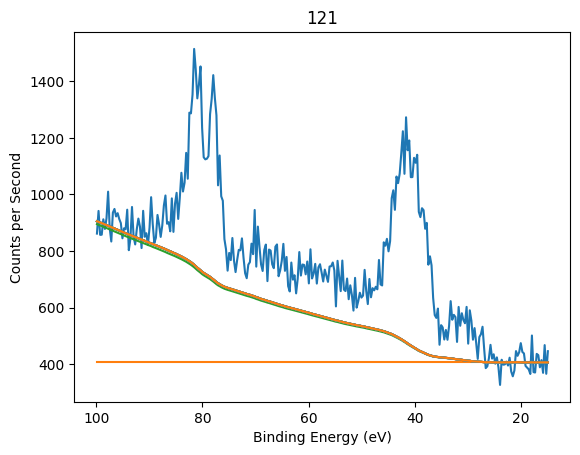

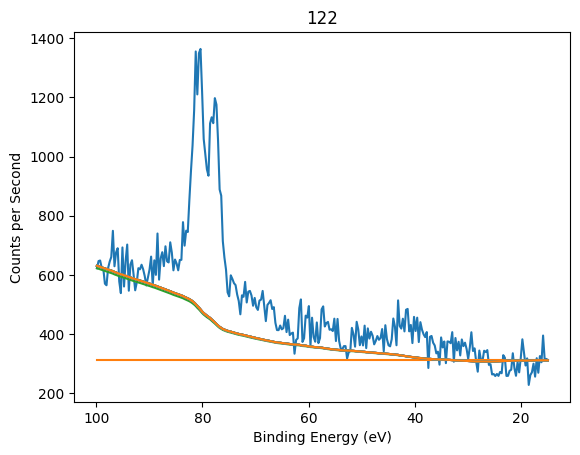

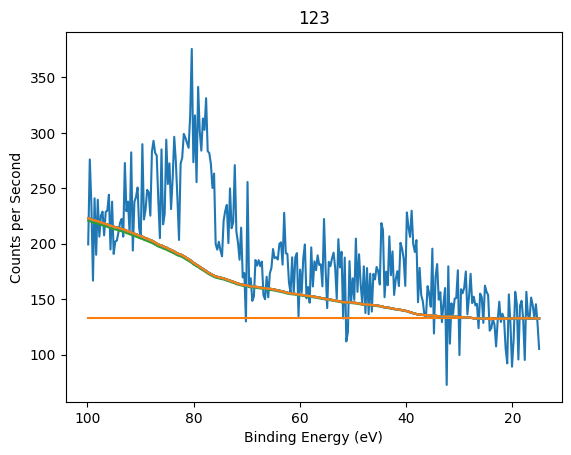

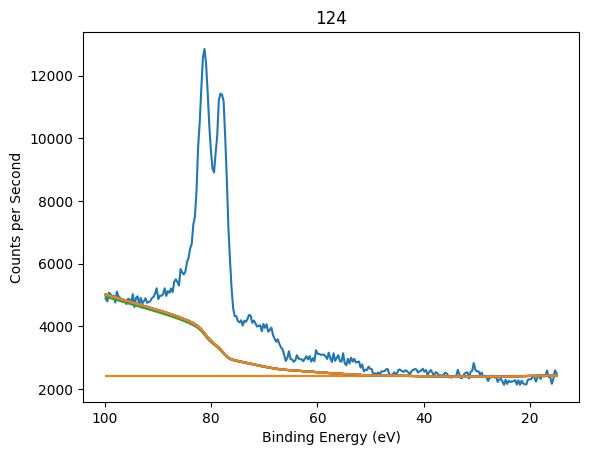

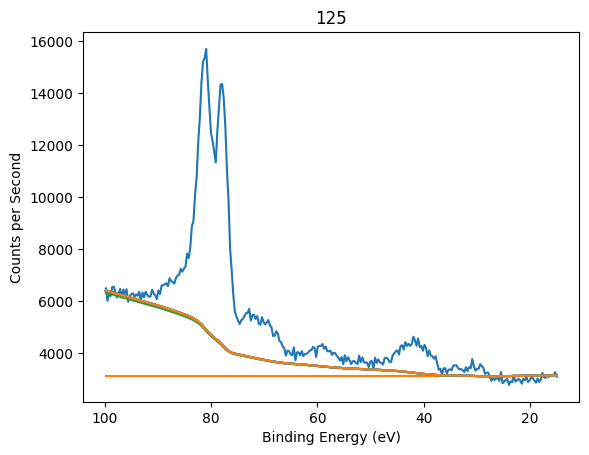

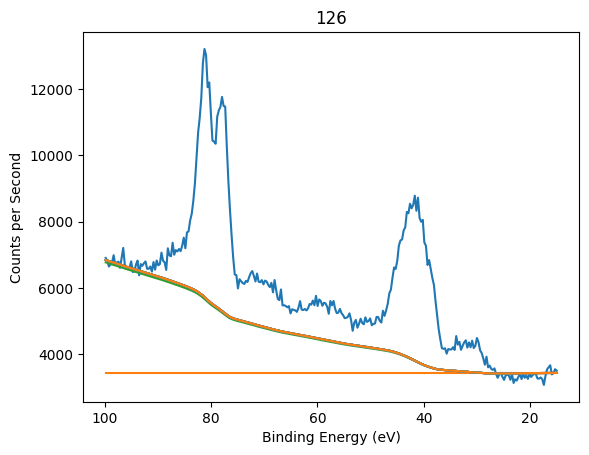

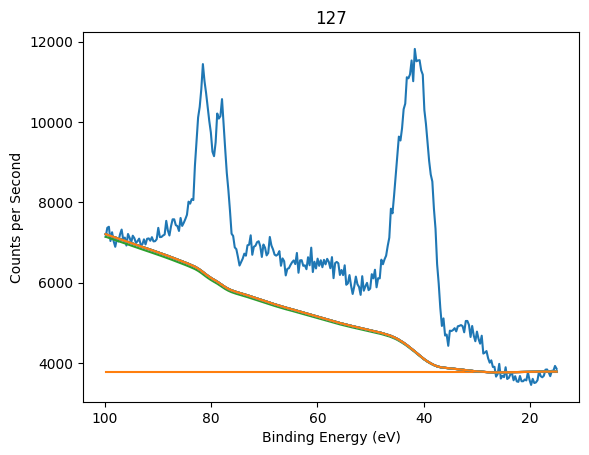

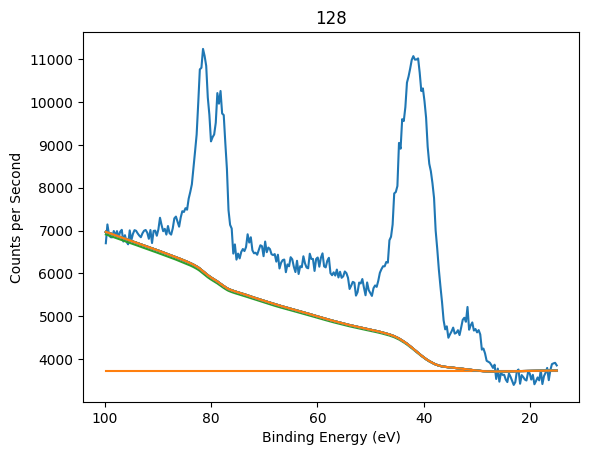

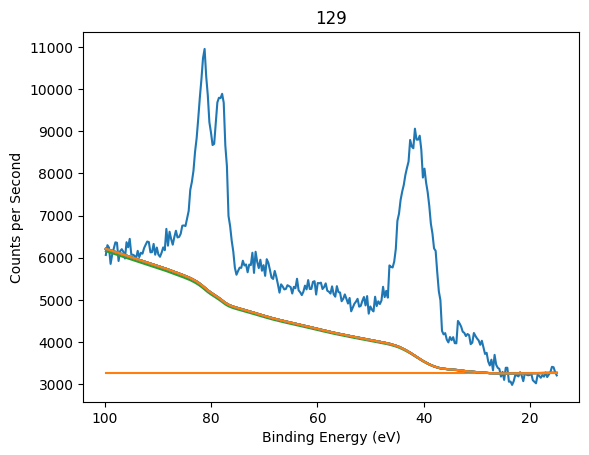

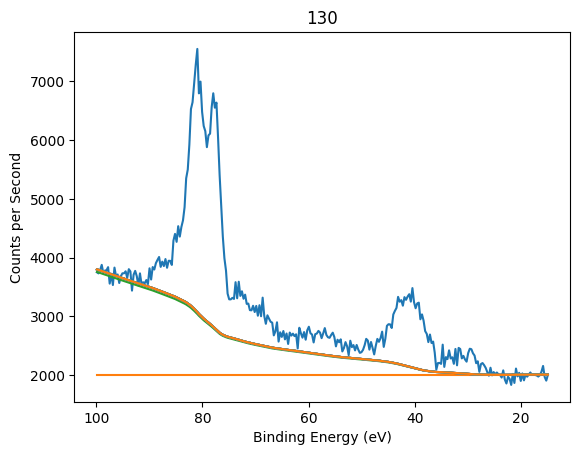

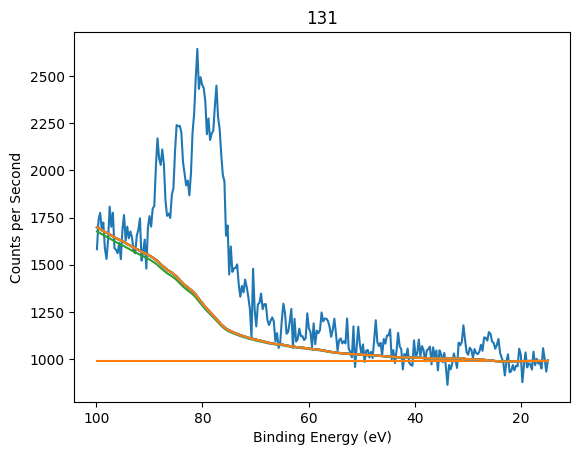

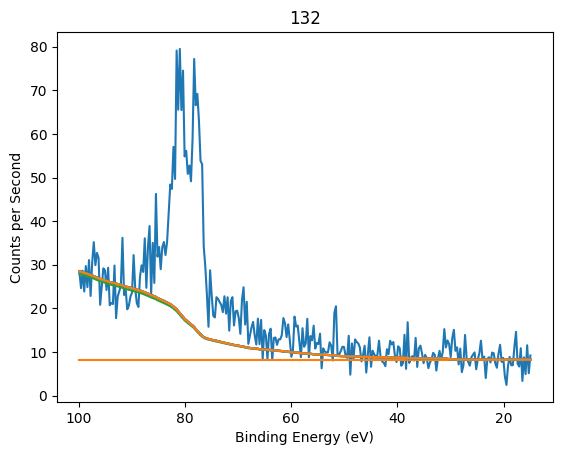

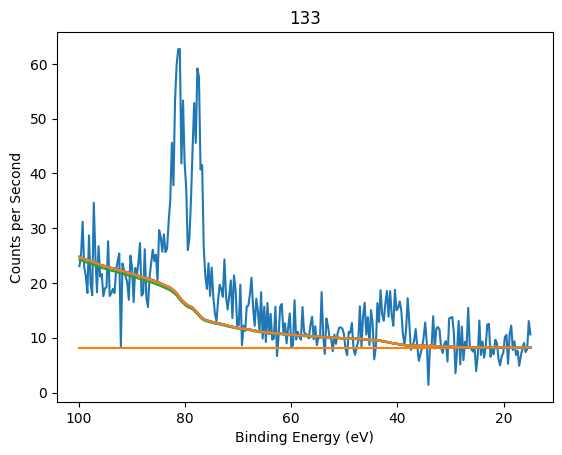

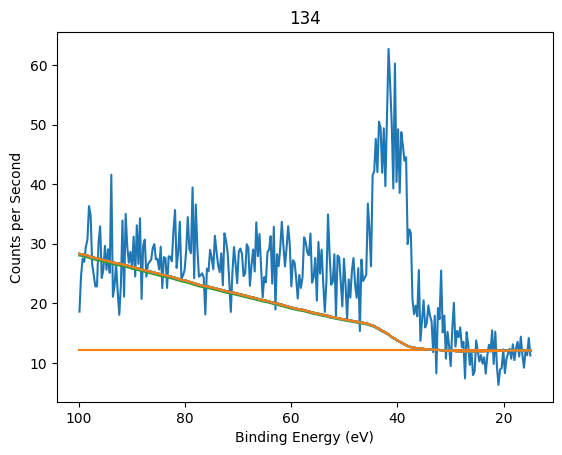

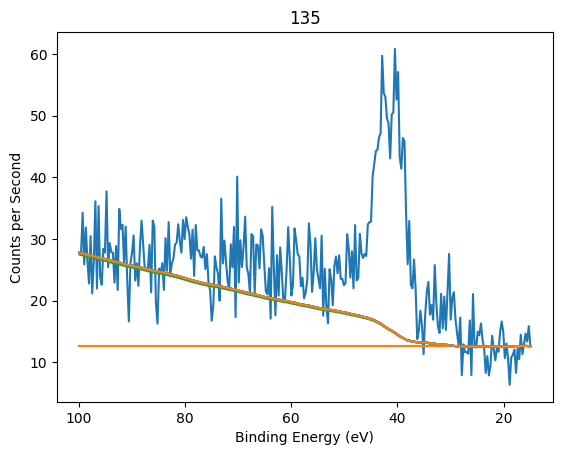

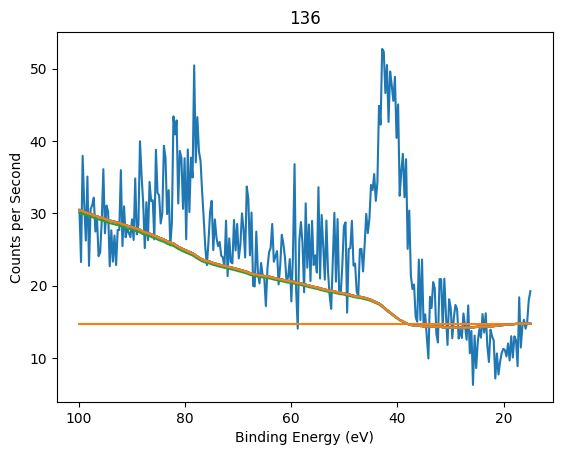

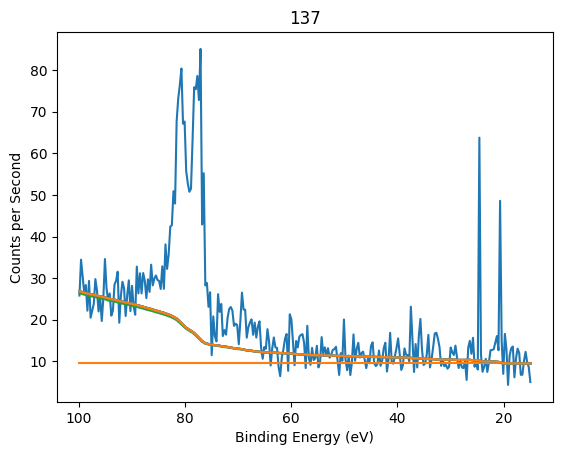

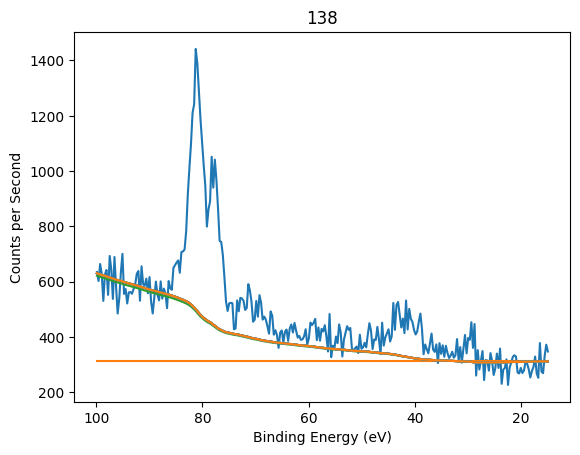

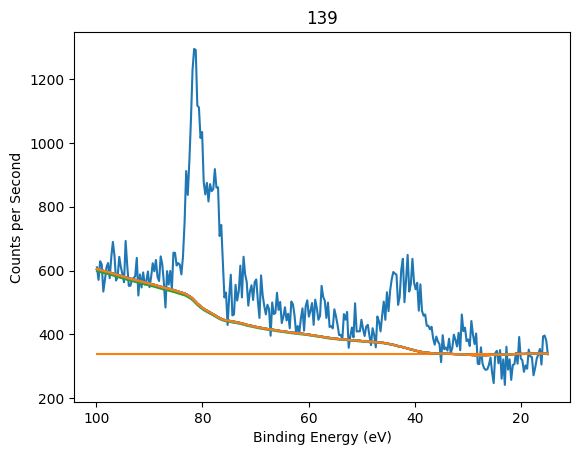

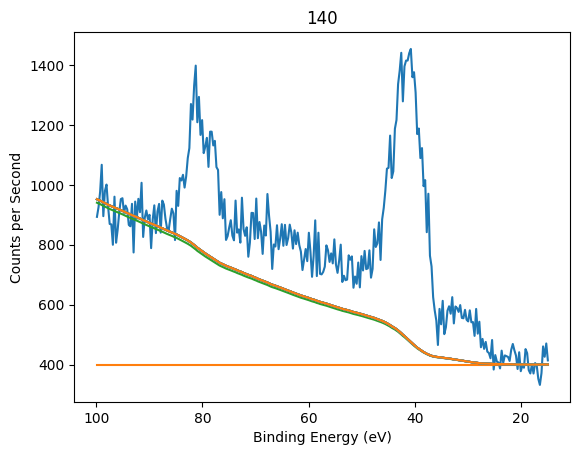

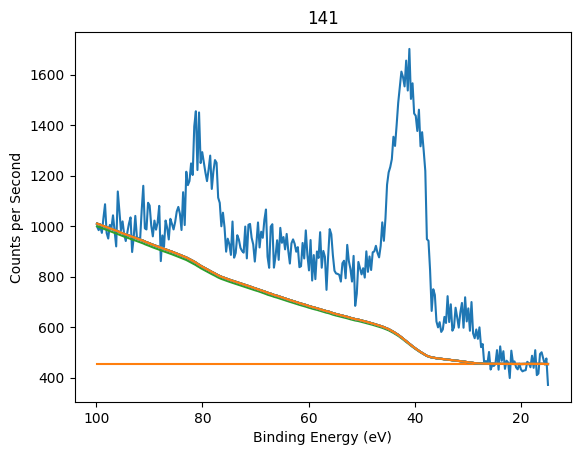

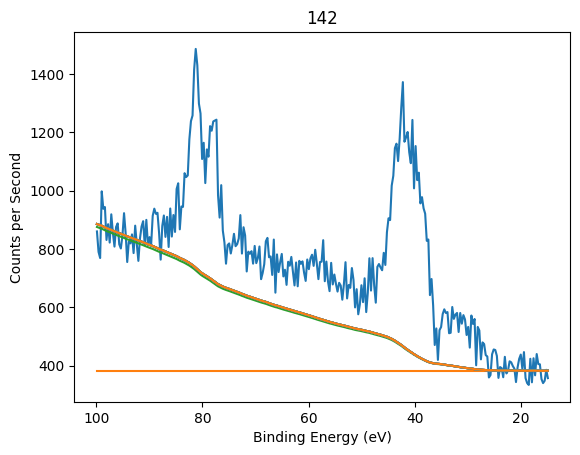

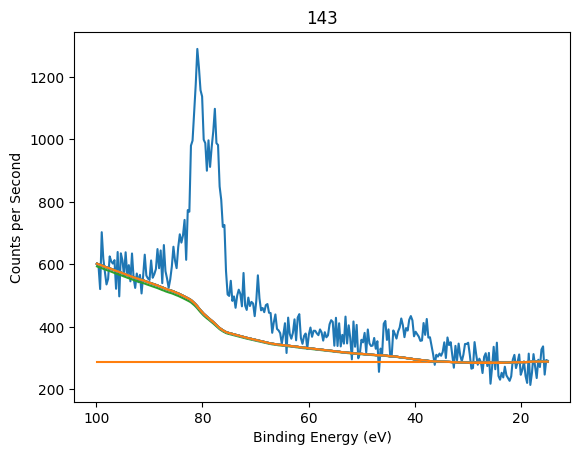

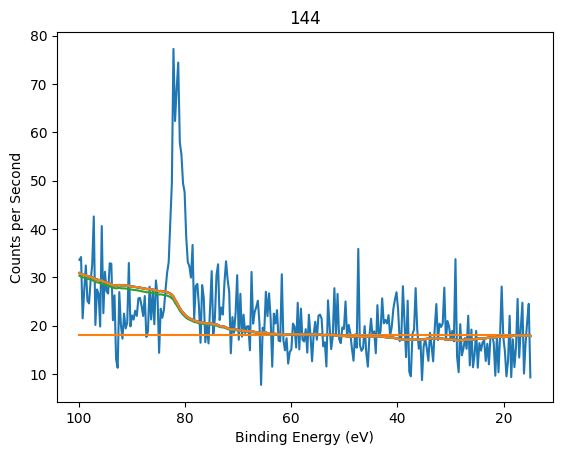

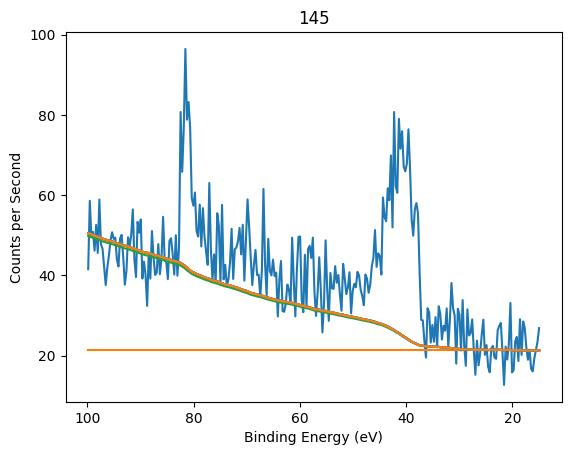

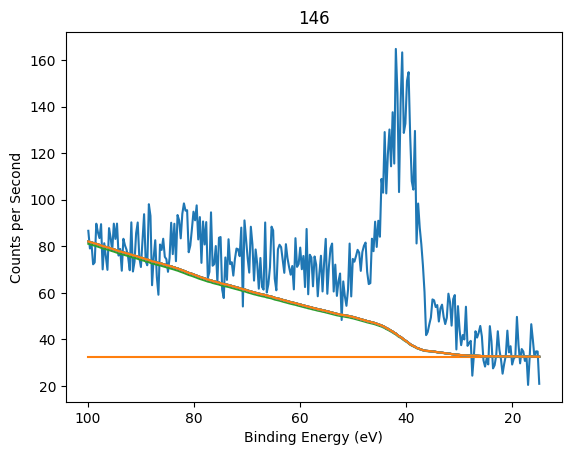

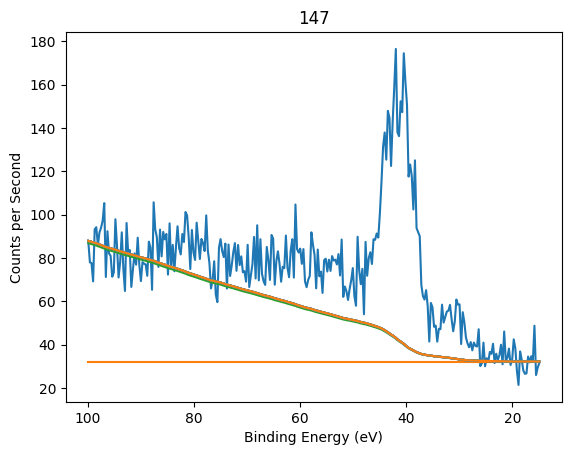

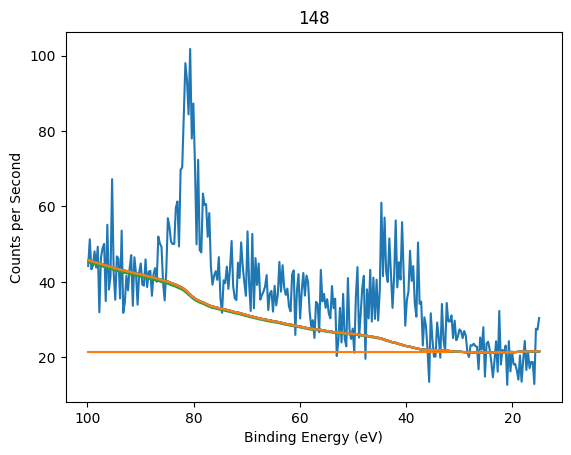

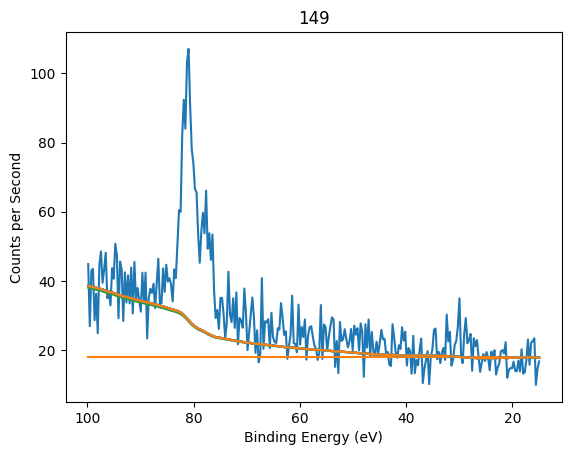

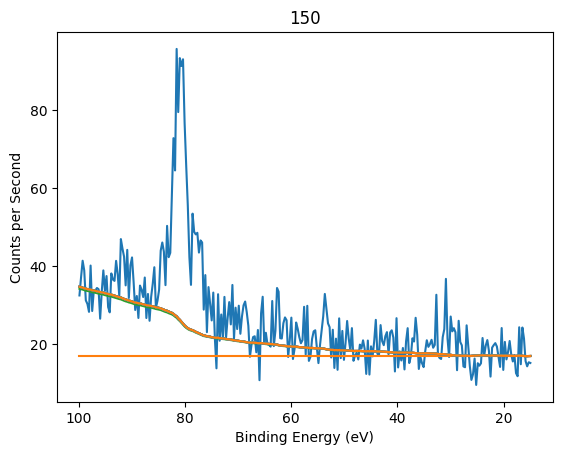

In [9]:
for index, spectrum in enumerate(data.spectra):
    if spectrum.name != 'W 4f and Pt 4f':
        continue
    spectrum.plot()
    backgrounds = shirley_background(spectrum.counts, 10)
    for background in backgrounds:
        plt.plot(spectrum.eV, background)
    plt.title(index)
    boilerplate()
    plt.show()